In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os

# ============================================================
# Configuration
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ============================================================
# Style helpers
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax):
    ax.text(0.97, 0.85, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$',
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment='right',
            verticalalignment='top',
            fontfamily="sans-serif")

# ============================================================
# Load PPFX weights
# ============================================================
flux = uproot.open(FLUX_FILE)

ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']

numu_values    = ppfx_numu.values()
numu_edges     = ppfx_numu.axes[0].edges()
numubar_values = ppfx_numubar.values()
numubar_edges  = ppfx_numubar.axes[0].edges()

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

onbeam_lt   = f["events/onbeam/Livetime"].values().sum()
offbeam_lt  = f["events/offbeam/Livetime"].values().sum()
rock_pot    = f["events/rock/POT"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}  (rock POT = {rock_pot:.4e})")

print("Loading MC preselection tree...")
mc      = f["events/nominal/preselection"].arrays(library="pd")
rock    = f["events/rock/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

# ============================================================
# Compute PPFX weights (nominal and rock)
# ============================================================
def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    mask_numu = (pdg == 14) & np.isfinite(nu_e)
    if mask_numu.sum() > 0:
        idx = np.searchsorted(numu_edges, nu_e[mask_numu]) - 1
        idx = np.clip(idx, 0, len(numu_values) - 1)
        w[mask_numu] = numu_values[idx]

    mask_numubar = (pdg == -14) & np.isfinite(nu_e)
    if mask_numubar.sum() > 0:
        idx = np.searchsorted(numubar_edges, nu_e[mask_numubar]) - 1
        idx = np.clip(idx, 0, len(numubar_values) - 1)
        w[mask_numubar] = numubar_values[idx]

    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w, mask_numu, mask_numubar

print("Computing PPFX weights (nominal)...")
ppfx_mc, mask_numu_mc, mask_numubar_mc = compute_ppfx(mc)
mc["ppfx_weight"] = ppfx_mc

print("Computing PPFX weights (rock)...")
ppfx_rock, mask_numu_rock, mask_numubar_rock = compute_ppfx(rock)
rock["ppfx_weight"] = ppfx_rock

print(f"Nominal: νμ {mask_numu_mc.sum()}, ν̄μ {mask_numubar_mc.sum()}, mean weight {ppfx_mc.mean():.4f}")
print(f"Rock:    νμ {mask_numu_rock.sum()}, ν̄μ {mask_numubar_rock.sum()}, mean weight {ppfx_rock.mean():.4f}")

# ============================================================
# Plot: No PPFX (left) | PPFX (middle) | Area normalized (right)
# ============================================================
def make_howard_plot(variable, xlabel, bins, range_, output_name, require_flash_match=False):

    fig = plt.figure(figsize=(17, 5))
    gs  = gridspec.GridSpec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.3)

    ax0  = fig.add_subplot(gs[0, 0])
    ax0r = fig.add_subplot(gs[1, 0], sharex=ax0)
    ax1  = fig.add_subplot(gs[0, 1])
    ax1r = fig.add_subplot(gs[1, 1], sharex=ax1)
    ax2  = fig.add_subplot(gs[0, 2])
    ax2r = fig.add_subplot(gs[1, 2], sharex=ax2)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    # Optional flash-match requirement (applied consistently to all samples)
    if require_flash_match:
        mc_mask      = (mc["reco_flash_time"]      > 0.0) & (mc["reco_flash_time"]      < 9.6)
        rock_mask    = (rock["reco_flash_time"]    > 0.0) & (rock["reco_flash_time"]    < 9.6)
        offbeam_mask = (offbeam["reco_flash_time"] > 0.0) & (offbeam["reco_flash_time"] < 9.6)
        onbeam_mask  = (onbeam["reco_flash_time"]  > 0.0) & (onbeam["reco_flash_time"]  < 9.6)
    else:
        mc_mask      = np.ones(len(mc),      dtype=bool)
        rock_mask    = np.ones(len(rock),    dtype=bool)
        offbeam_mask = np.ones(len(offbeam), dtype=bool)
        onbeam_mask  = np.ones(len(onbeam),  dtype=bool)

    # Histograms
    w_mc_noppfx   = np.ones(mc_mask.sum())   * mc_scale
    w_mc_ppfx     = mc.loc[mc_mask, "ppfx_weight"].values * mc_scale
    w_rock_noppfx = np.ones(rock_mask.sum()) * rock_scale
    w_rock_ppfx   = rock.loc[rock_mask, "ppfx_weight"].values * rock_scale

    mc_noppfx,   _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_noppfx)
    mc_ppfx,     _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_ppfx)
    rock_noppfx, _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_noppfx)
    rock_ppfx,   _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_ppfx)
    offbeam_h,   _ = np.histogram(offbeam.loc[offbeam_mask, variable].values, bins=bins, range=range_)
    onbeam_h,    _ = np.histogram(onbeam.loc[onbeam_mask, variable].values,   bins=bins, range=range_)
    onbeam_err     = np.sqrt(onbeam_h)

    offbeam_pot  = offbeam_h * offbeam_scale
    pred_noppfx  = mc_noppfx + rock_noppfx + offbeam_pot
    pred_ppfx    = mc_ppfx   + rock_ppfx   + offbeam_pot

    # Area normalized (no PPFX needed - shape comparison only)
    total_data        = onbeam_h.sum()
    norm_factor       = total_data / pred_noppfx.sum() if pred_noppfx.sum() > 0 else 1.0
    mc_area_f          = mc_noppfx   * norm_factor / total_data
    rock_area_f         = rock_noppfx * norm_factor / total_data
    offbeam_area_f      = offbeam_pot * norm_factor / total_data
    pred_area_f          = pred_noppfx * norm_factor / total_data
    onbeam_area_f   = onbeam_h   / total_data
    onbeam_err_f    = onbeam_err / total_data

    def draw_panel(ax, mc_vals, rock_vals, offbeam_vals, pred_vals,
                   data_vals, data_err, ylabel, pot_str, ppfx=False):
        bottoms = np.zeros(len(bins) - 1)
        ax.bar(bin_centers, mc_vals, width=bin_width, bottom=bottoms,
               color="#003087", alpha=0.7, label=r"$\nu$ + cosmic sim.")
        bottoms = bottoms + mc_vals
        ax.bar(bin_centers, rock_vals, width=bin_width, bottom=bottoms,
               color="seagreen", alpha=0.7, label="Rock muons")
        bottoms = bottoms + rock_vals
        ax.bar(bin_centers, offbeam_vals, width=bin_width, bottom=bottoms,
               color="orange",  alpha=0.7, label="Offbeam (in-time cosmic)")
        ax.step(np.append(bins[:-1], bins[-1]),
                np.append(pred_vals, pred_vals[-1]),
                where='post', color='black', linewidth=1.5,
                label=f"Prediction ({pred_vals.sum():.1f})" if pred_vals.sum() > 1.5 else "Prediction (Area Norm.)")
        ax.errorbar(bin_centers, data_vals, yerr=data_err,
                    fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                    label=f"Data ({int(total_data)})", zorder=5)
        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ymax = ax.get_ylim()[1]
        ax.set_ylim(0, ymax * 1.5)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1], fontsize=8, loc='upper left',
                  framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str)
        if ppfx:
            add_ppfx_label(ax)

    def draw_ratio(ax, pred_vals, data_vals, data_err, xlabel):
        with np.errstate(invalid="ignore", divide="ignore"):
            ratio     = np.where(pred_vals > 0, data_vals / pred_vals, np.nan)
            ratio_err = np.where(pred_vals > 0, data_err  / pred_vals, np.nan)
        ax.errorbar(bin_centers, ratio, yerr=ratio_err,
                    fmt='o', markersize=4,
                    markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    # Left: no PPFX
    draw_panel(ax0, mc_noppfx, rock_noppfx, offbeam_pot, pred_noppfx,
               onbeam_h, onbeam_err,
               ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT",
               ppfx=False)
    draw_ratio(ax0r, pred_noppfx, onbeam_h, onbeam_err, xlabel)

    # Middle: with PPFX
    draw_panel(ax1, mc_ppfx, rock_ppfx, offbeam_pot, pred_ppfx,
               onbeam_h, onbeam_err,
               ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT",
               ppfx=True)
    draw_ratio(ax1r, pred_ppfx, onbeam_h, onbeam_err, xlabel)

    # Right: area normalized (no PPFX)
    draw_panel(ax2, mc_area_f, rock_area_f, offbeam_area_f, pred_area_f,
               onbeam_area_f, onbeam_err_f,
               ylabel=r"$\mathbf{Fraction\ /\ Bin}$",
               pot_str="Area Normalized",
               ppfx=False)
    draw_ratio(ax2r, pred_area_f, onbeam_area_f, onbeam_err_f, xlabel)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

# ============================================================
# Generate plots
# ============================================================
make_howard_plot("reco_flash_time",     "Flash Time [us]",              np.linspace(-5, 15, 51),      (-5, 15),      output_name="preselection_flash_time")
make_howard_plot("reco_flash_total_pe", "Flash Total PE",               np.linspace(0, 5000, 51),     (0, 5000),     output_name="preselection_flash_total_pe")
make_howard_plot("reco_vertex_x",       "Reconstructed Vertex X [cm]",  np.linspace(-400, 400, 51),   (-400, 400),   output_name="preselection_vertex_x", require_flash_match=True)
make_howard_plot("reco_vertex_z",       "Reconstructed Vertex Z [cm]",  np.linspace(-1000, 1000, 51), (-1000, 1000), output_name="preselection_vertex_z", require_flash_match=True)
make_howard_plot("reco_vertex_y",       "Reconstructed Vertex Y [cm]",  np.linspace(-200, 200, 51),   (-200, 200),   output_name="preselection_vertex_y", require_flash_match=True)
make_howard_plot("reco_leading_muon_length", "Muon Candidate Length [cm]", np.linspace(0, 400, 51),    (0, 400),      output_name="preselection_track_length", require_flash_match=True)

print("Done.")

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

CATEGORY_LABELS = {
    0:  "Signal (QE)",
    1:  "Signal (QE)",
    2:  "OOFV",
    3:  "Signal (RES)",
    4:  "Signal (other)",
    5:  "OOFV",
    6:  "Other CC",
    7:  "Other CC",
    8:  "Other CC",
    9:  "ν NC",
    10: "Cosmic",
}

CATEGORY_COLORS = {
    0:  "#003087",
    1:  "#003087",
    2:  "#2E8B57",
    3:  "#003087",
    4:  "#003087",
    5:  "#2E8B57",
    6:  "#FFD100",
    7:  "#FFD100",
    8:  "#FFD100",
    9:  "#CC0000",
    10: "#FF69B4",
}

f = uproot.open(DATA_FILE)
rock = f["events/rock/preselection"].arrays(library="pd")

cats = rock["true_category"].value_counts().sort_index()
total = cats.sum()

print("Rock preselection true_category breakdown:")
print(f"{'Category':>10} {'Label':>20} {'Count':>10} {'Fraction':>10}")
print("-" * 55)
for cat, count in cats.items():
    label = CATEGORY_LABELS.get(int(cat), f"Unknown ({cat})")
    print(f"{cat:>10.0f} {label:>20} {count:>10} {count/total:>10.2%}")
print(f"{'TOTAL':>10} {'':>20} {total:>10}")

# Plot
fig, ax = plt.subplots(figsize=(6, 4))
fig.subplots_adjust(bottom=0.15)

bars = ax.bar(
    [str(int(c)) for c in cats.index],
    cats.values / total * 100,
    color=[CATEGORY_COLORS.get(int(c), "grey") for c in cats.index],
    alpha=0.85, edgecolor='black', linewidth=0.5
)

for bar, (cat, count) in zip(bars, cats.items()):
    label = CATEGORY_LABELS.get(int(cat), f"?")
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f"{label}\n{count/total:.1%}",
            ha='center', va='bottom', fontsize=7, fontfamily='sans-serif')

ax.set_xlabel(r"$\mathbf{True\ Category}$", fontsize=12)
ax.set_ylabel(r"$\mathbf{Fraction\ [\%]}$", fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
ax.grid(True, alpha=0.3, axis='y')

yrange = ax.get_ylim()
xrange = ax.get_xlim()
usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
ax.text(usex, usey,
        r'$\bf{ICARUS \cdot NuMI}$' + ' Rock Sample\nWork-in-Progress',
        fontsize=9, color="chocolate",
        verticalalignment="bottom", fontfamily="sans-serif")

ax.set_ylim(0, ax.get_ylim()[1] * 1.4)

os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pdf/rock_category_breakdown.pdf"),   bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/rock_category_breakdown.jpeg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
print("Saved: rock_category_breakdown")

In [ ]:
"""
Overlap between the 1muNp0pi (this analysis) and Howard's CC0piNp (CC mesonless,
SBN DocDB 47077 ref [9]) signal definitions.

Computed on the truth-level signal tree of the nominal MC:
    events/nominal/signal  in  1muNp0pi_Nge1_uncontained.root

Logic
-----
Both analyses share the same muon threshold (p_mu > 226 MeV/c, equivalently
KE_mu > 143.425 MeV) and both include numu + numubar CC, so within our signal
tree the only discriminating requirements from Howard's definition are:

  (1) Leading proton momentum in [0.4, 1.0] GeV/c
      (ours: any proton with KE > 50 MeV, i.e. p > 0.310 GeV/c, no upper bound)

  (2) No primary charged pion at ANY energy
      (ours: none above 25 MeV KE, so only primary pions BELOW 25 MeV can
      distinguish the two definitions inside our signal)

Caveat on (2): the true_leading_pion_* branches are filled by the leading_pion
selector (selectors.h), which loops over ALL pions in the interaction with no
primary requirement. The signal definition itself uses pion_multiplicity
(variables.h), which counts only PRIMARY pions with KE >= 25 MeV. Therefore:
  - entries with true_leading_pion_ke > 25 MeV are necessarily NON-primary
    (Geant4 secondaries) -> irrelevant to both signal definitions;
  - entries with true_leading_pion_ke < 25 MeV are an UPPER BOUND on events
    with a soft primary pion (some are soft secondaries).

Not evaluable from these branches (neglected): Howard's photon (>10 MeV) and
other-hadron checks, and fiducial-volume differences.

Counts are raw MC events (no flux/PPFX/CV weights).
"""

import numpy as np
import uproot

FNAME = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
TREE = "events/nominal/signal"

P_LOW, P_HIGH = 0.4, 1.0   # Howard leading-proton window [GeV/c]
PI_THR = 25.0              # our primary charged-pion KE threshold [MeV]

tree = uproot.open(FNAME)[TREE]
arr = tree.arrays(
    ["true_leading_proton_momentum",   # GeV/c
     "true_leading_pion_ke"],          # MeV; NaN if no pion of any kind
    library="np",
)

p_lp = arr["true_leading_proton_momentum"]
pi_ke = arr["true_leading_pion_ke"]
n = len(p_lp)

# Sanity check: our proton threshold KE > 50 MeV corresponds to
# p = sqrt((50 + 938.272)^2 - 938.272^2) = 310 MeV/c, so the minimum
# leading-proton momentum in the tree should be ~0.310 GeV/c.
print(f"entries in signal tree           : {n}")
print(f"min leading proton momentum      : {np.min(p_lp):.4f} GeV/c (expect ~0.310)\n")

# --- (1) Howard's leading-proton window --------------------------------------
in_window = (p_lp > P_LOW) & (p_lp < P_HIGH)
below = p_lp <= P_LOW
above = p_lp >= P_HIGH

# --- (2) pion bookkeeping -----------------------------------------------------
has_pion_branch = ~np.isnan(pi_ke)              # any pion, primary or not
pion_above_thr = has_pion_branch & (pi_ke > PI_THR)   # necessarily non-primary
pion_below_thr = has_pion_branch & (pi_ke <= PI_THR)  # upper bound on soft primaries

print(f"pion branch filled (any pion)    : {has_pion_branch.sum()}")
print(f"  KE > {PI_THR:.0f} MeV (non-primary)     : {pion_above_thr.sum()}")
print(f"  KE <= {PI_THR:.0f} MeV (soft, upper bnd): {pion_below_thr.sum()} "
      f"({100*pion_below_thr.mean():.2f}% of signal)\n")

# --- Overlap ------------------------------------------------------------------
# Central value: proton window only (soft-primary-pion correction is < 0.2%,
# below the precision of this estimate).
overlap = in_window
# Lower bound: additionally drop every event with any pion below threshold.
overlap_lb = in_window & ~pion_below_thr

def line(label, mask):
    print(f"{label:45s}: {mask.sum():6d}  ({100*mask.mean():.1f}%)")

line(f"leading proton in ({P_LOW}, {P_HIGH}) GeV/c", in_window)
line(f"leading proton <= {P_LOW} GeV/c", below)
line(f"leading proton >= {P_HIGH} GeV/c", above)
print()
line("OVERLAP (window only, central value)", overlap)
line("overlap minus soft-pion upper bound", overlap_lb)

In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# Configuration (self-contained: duplicated from the main config cell
# so this cell can run on its own without executing earlier cells)
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"
OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ============================================================
# Style helpers (duplicated from the main plotting cell)
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax):
    ax.text(0.97, 0.85, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$',
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment='right',
            verticalalignment='top',
            fontfamily="sans-serif")

# ============================================================
# Load PPFX weights
# ============================================================
flux = uproot.open(FLUX_FILE)

ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']

numu_values    = ppfx_numu.values()
numu_edges     = ppfx_numu.axes[0].edges()
numubar_values = ppfx_numubar.values()
numubar_edges  = ppfx_numubar.axes[0].edges()

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

rock_pot   = f["events/rock/POT"].values().sum()
mc_scale   = ONBEAM_POT / NOMINAL_POT
rock_scale = ONBEAM_POT / rock_pot

mc   = f["events/nominal/preselection"].arrays(library="pd")
rock = f["events/rock/preselection"].arrays(library="pd")

# ============================================================
# Compute PPFX weights
# ============================================================
def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    mask_numu = (pdg == 14) & np.isfinite(nu_e)
    if mask_numu.sum() > 0:
        idx = np.searchsorted(numu_edges, nu_e[mask_numu]) - 1
        idx = np.clip(idx, 0, len(numu_values) - 1)
        w[mask_numu] = numu_values[idx]

    mask_numubar = (pdg == -14) & np.isfinite(nu_e)
    if mask_numubar.sum() > 0:
        idx = np.searchsorted(numubar_edges, nu_e[mask_numubar]) - 1
        idx = np.clip(idx, 0, len(numubar_values) - 1)
        w[mask_numubar] = numubar_values[idx]

    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w

mc["ppfx_weight"]   = compute_ppfx(mc)
rock["ppfx_weight"] = compute_ppfx(rock)

# ============================================================
# Plot: True neutrino energy (MC-only, PPFX-weighted, single panel)
# ============================================================
def make_mc_stack_plot(variable, xlabel, bins, range_, output_name, require_flash_match=False):

    fig, ax = plt.subplots(figsize=(17/3, 5))

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    if require_flash_match:
        mc_mask   = (mc["reco_flash_time"]   > 0.0) & (mc["reco_flash_time"]   < 9.6)
        rock_mask = (rock["reco_flash_time"] > 0.0) & (rock["reco_flash_time"] < 9.6)
    else:
        mc_mask   = np.ones(len(mc),   dtype=bool)
        rock_mask = np.ones(len(rock), dtype=bool)

    w_mc_ppfx   = mc.loc[mc_mask, "ppfx_weight"].values   * mc_scale
    w_rock_ppfx = rock.loc[rock_mask, "ppfx_weight"].values * rock_scale

    mc_ppfx,   _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_ppfx)
    rock_ppfx, _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_ppfx)
    pred_ppfx    = mc_ppfx + rock_ppfx

    bottoms = np.zeros(len(bins) - 1)
    ax.bar(bin_centers, mc_ppfx, width=bin_width, bottom=bottoms,
           color="#003087", alpha=0.7, label=r"$\nu$ + cosmic sim.")
    bottoms = bottoms + mc_ppfx
    ax.bar(bin_centers, rock_ppfx, width=bin_width, bottom=bottoms,
           color="seagreen", alpha=0.7, label="Rock muons")
    ax.step(np.append(bins[:-1], bins[-1]),
            np.append(pred_ppfx, pred_ppfx[-1]),
            where='post', color='black', linewidth=1.5,
            label=f"Prediction ({pred_ppfx.sum():.1f})")

    ax.set_ylabel(r"$\mathbf{Events\ /\ Bin}$", fontsize=11, fontfamily="sans-serif", fontweight='bold')
    ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
    ax.grid(True, alpha=0.3)
    apply_tick_style(ax)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.5)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], fontsize=8, loc='upper left',
              framealpha=0.0, edgecolor='none')
    add_icarus_label(ax)
    add_pot_label(ax, f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT")
    add_ppfx_label(ax)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

make_mc_stack_plot("true_neutrino_energy", "True Neutrino Energy [GeV]",
                    np.linspace(0, 4, 51), (0, 4),
                    output_name="preselection_true_neutrino_energy",
                    require_flash_match=True)


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ============================================================
# Configuration (self-contained: duplicated from the main config cell
# so this cell can run on its own without executing earlier cells)
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"
OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ============================================================
# Style helpers (duplicated from the main plotting cell)
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=8, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax, x=0.97, y=0.85, ha='right'):
    ax.text(x, y, "GENIE v3.04.00: AR23_20i_00_000\nPPFX Reweight Applied",
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment=ha,
            verticalalignment='top',
            fontfamily="sans-serif")

# ============================================================
# Load PPFX weights
# ============================================================
flux = uproot.open(FLUX_FILE)

ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']

numu_values    = ppfx_numu.values()
numu_edges     = ppfx_numu.axes[0].edges()
numubar_values = ppfx_numubar.values()
numubar_edges  = ppfx_numubar.axes[0].edges()

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

rock_pot   = f["events/rock/POT"].values().sum()
mc_scale   = ONBEAM_POT / NOMINAL_POT
rock_scale = ONBEAM_POT / rock_pot

mc   = f["events/nominal/preselection"].arrays(library="pd")
rock = f["events/rock/preselection"].arrays(library="pd")

# ============================================================
# Compute PPFX weights
# ============================================================
def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    mask_numu = (pdg == 14) & np.isfinite(nu_e)
    if mask_numu.sum() > 0:
        idx = np.searchsorted(numu_edges, nu_e[mask_numu]) - 1
        idx = np.clip(idx, 0, len(numu_values) - 1)
        w[mask_numu] = numu_values[idx]

    mask_numubar = (pdg == -14) & np.isfinite(nu_e)
    if mask_numubar.sum() > 0:
        idx = np.searchsorted(numubar_edges, nu_e[mask_numubar]) - 1
        idx = np.clip(idx, 0, len(numubar_values) - 1)
        w[mask_numubar] = numubar_values[idx]

    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w

mc["ppfx_weight"]   = compute_ppfx(mc)
rock["ppfx_weight"] = compute_ppfx(rock)

# ============================================================
# Plot: True neutrino energy, GENIE interaction-mode breakdown (MC-only)
# ============================================================
# NOTE: uses "true_interaction_mode" as confirmed. Values below follow the
# common GENIE ScatteringType convention (QE=0, RES=1, DIS=2, COH=3, MEC=10).
# Run the value_counts print below first and adjust MODE_LABELS/MODE_COLORS
# if your branch uses a different encoding.

MODE_LABELS = {
    0:  "QE",
    1:  "RES",
    2:  "DIS",
    10: "MEC",
}

MODE_COLORS = {
    0:  "#003087",  # QE  - dark blue
    1:  "seagreen", # RES - green
    2:  "cornflowerblue",  # DIS - light blue
    10: "orange",   # MEC - orange
}

# Stacking / legend order (bottom to top), matching the reference plot's
# process ordering and color scheme: QE, MEC, RES, DIS.
MODE_ORDER = [0, 10, 1, 2]

modes_seen = mc["true_interaction_mode"].value_counts().sort_index()
print("true_interaction_mode breakdown (nominal MC, unweighted counts):")
print(f"{'Mode':>6} {'Label':>8} {'Count':>10} {'Fraction':>10}")
print("-" * 40)
for m, count in modes_seen.items():
    label = MODE_LABELS.get(int(m), f"Unknown ({m})")
    print(f"{m:>6.0f} {label:>8} {count:>10} {count/modes_seen.sum():>10.2%}")

def make_mode_stack_plot(variable, xlabel, bins, range_, output_name, require_flash_match=False):

    fig, ax = plt.subplots(figsize=(17/3, 5))

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    if require_flash_match:
        mc_mask = (mc["reco_flash_time"] > 0.0) & (mc["reco_flash_time"] < 9.6)
    else:
        mc_mask = np.ones(len(mc), dtype=bool)

    sel = mc.loc[mc_mask]
    modes_present = [m for m in MODE_ORDER if (sel["true_interaction_mode"] == m).any()]

    # Raw MC (nominal POT), PPFX-weighted only -- no scaling to data/onbeam POT.
    per_mode_hist = {}
    for m in modes_present:
        mode_mask = sel["true_interaction_mode"] == m
        w = sel.loc[mode_mask, "ppfx_weight"].values
        h, _ = np.histogram(sel.loc[mode_mask, variable].values, bins=bins, range=range_, weights=w)
        per_mode_hist[m] = h
    total_h = sum(per_mode_hist.values())

    bottoms = np.zeros(len(bins) - 1)
    pred = np.zeros(len(bins) - 1)
    for m in modes_present:
        h = per_mode_hist[m]
        frac = h.sum() / total_h.sum() if total_h.sum() > 0 else 0.0
        ax.bar(bin_centers, h, width=bin_width, bottom=bottoms,
               color=MODE_COLORS.get(m, "grey"), alpha=0.8,
               label=f"{MODE_LABELS[m]}: {frac:.0%}")
        bottoms = bottoms + h
        pred = pred + h

    ax.step(np.append(bins[:-1], bins[-1]),
            np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5,
            label='_nolegend_')

    ax.set_ylabel("Interactions", fontsize=11, fontfamily="sans-serif", fontweight='bold')
    ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
    apply_tick_style(ax)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.2)
    handles, labels = ax.get_legend_handles_labels()
    # Unfilled outline box for the total, matching the reference plot's legend
    # style (momentum cut text will be added to this entry later).
    total_handle = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5)
    handles.append(total_handle)
    labels.append(r"$\nu_\mu,\ \bar{\nu}_\mu$: AV, $p_\mu>226$ MeV/c")
    legend = ax.legend(handles, labels, fontsize=8, loc='upper right',
              framealpha=0.0, edgecolor='none')
    add_icarus_label(ax)
    add_pot_label(ax, f"NuMI MC {NOMINAL_POT/1e20:.3f}" + r"$\times 10^{20}$ POT")

    add_ppfx_label(ax, x=0.03, y=0.95, ha='left')

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

make_mode_stack_plot("true_neutrino_energy", "True Neutrino Energy [GeV]",
                     np.linspace(0, 4, 51), (0, 4),
                     output_name="preselection_true_neutrino_energy_by_mode",
                     require_flash_match=True)


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ============================================================
# Configuration (self-contained: duplicated from the main config cell
# so this cell can run on its own without executing earlier cells)
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"
OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ============================================================
# Style helpers (duplicated from the main plotting cell)
# ============================================================
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=8, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax, x=0.03, y=0.95, ha='left'):
    ax.text(x, y, "GENIE v3.04.00: AR23_20i_00_000\nPPFX Reweight Applied",
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment=ha,
            verticalalignment='top',
            fontfamily="sans-serif")

# ============================================================
# Load PPFX weights (nue / nuebar flux histograms)
# ============================================================
flux = uproot.open(FLUX_FILE)

ppfx_nue    = flux[f'ppfx_flux_weights/hweights_{horn_current}_nue;1']
ppfx_nuebar = flux[f'ppfx_flux_weights/hweights_{horn_current}_nuebar;1']

nue_values    = ppfx_nue.values()
nue_edges     = ppfx_nue.axes[0].edges()
nuebar_values = ppfx_nuebar.values()
nuebar_edges  = ppfx_nuebar.axes[0].edges()

# ============================================================
# Load data
# ============================================================
f = uproot.open(DATA_FILE)

rock_pot   = f["events/rock/POT"].values().sum()
mc_scale   = ONBEAM_POT / NOMINAL_POT
rock_scale = ONBEAM_POT / rock_pot

mc = f["events/nominal/preselection"].arrays(library="pd")

# ============================================================
# Compute PPFX weights for the electron-neutrino component
# (pdg = +-12; weight = 1 for everything else, i.e. non-nue events
# are excluded downstream by the true_pdg selection below anyway)
# ============================================================
def compute_ppfx_nue(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    mask_nue = (pdg == 12) & np.isfinite(nu_e)
    if mask_nue.sum() > 0:
        idx = np.searchsorted(nue_edges, nu_e[mask_nue]) - 1
        idx = np.clip(idx, 0, len(nue_values) - 1)
        w[mask_nue] = nue_values[idx]

    mask_nuebar = (pdg == -12) & np.isfinite(nu_e)
    if mask_nuebar.sum() > 0:
        idx = np.searchsorted(nuebar_edges, nu_e[mask_nuebar]) - 1
        idx = np.clip(idx, 0, len(nuebar_values) - 1)
        w[mask_nuebar] = nuebar_values[idx]

    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w

mc["ppfx_weight_nue"] = compute_ppfx_nue(mc)

# ============================================================
# Plot: True neutrino energy, GENIE interaction-mode breakdown
# for the intrinsic electron-neutrino (nue + nuebar) component (MC-only)
# ============================================================
# NOTE: uses "true_interaction_mode" as confirmed. Values below follow the
# common GENIE ScatteringType convention (QE=0, RES=1, DIS=2, COH=3, MEC=10).
# Run the value_counts print below first and adjust MODE_LABELS/MODE_COLORS
# if your branch uses a different encoding.

MODE_LABELS = {
    0:  "QE",
    1:  "RES",
    2:  "DIS",
    10: "MEC",
}

MODE_COLORS = {
    0:  "#003087",  # QE  - dark blue
    1:  "seagreen", # RES - green
    2:  "cornflowerblue",  # DIS - light blue
    10: "orange",   # MEC - orange
}

# Stacking / legend order (bottom to top), matching the reference plot's
# process ordering and color scheme: QE, MEC, RES, DIS.
MODE_ORDER = [0, 10, 1, 2]

nue_mask_all = mc["true_pdg"].isin([12, -12])
modes_seen = mc.loc[nue_mask_all, "true_interaction_mode"].value_counts().sort_index()
print("true_interaction_mode breakdown (nominal MC, nue + nuebar only, unweighted counts):")
print(f"{'Mode':>6} {'Label':>8} {'Count':>10} {'Fraction':>10}")
print("-" * 40)
for m, count in modes_seen.items():
    label = MODE_LABELS.get(int(m), f"Unknown ({m})")
    print(f"{m:>6.0f} {label:>8} {count:>10} {count/modes_seen.sum():>10.2%}")

def make_nue_mode_stack_plot(variable, xlabel, bins, range_, output_name, require_flash_match=False):

    fig, ax = plt.subplots(figsize=(17/3, 5))

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    if require_flash_match:
        base_mask = (mc["reco_flash_time"] > 0.0) & (mc["reco_flash_time"] < 9.6)
    else:
        base_mask = np.ones(len(mc), dtype=bool)

    # Restrict to the intrinsic electron-neutrino component only.
    mc_mask = base_mask & mc["true_pdg"].isin([12, -12])

    sel = mc.loc[mc_mask]
    modes_present = [m for m in MODE_ORDER if (sel["true_interaction_mode"] == m).any()]

    # Raw MC (nominal POT), PPFX-weighted only -- no scaling to data/onbeam POT.
    per_mode_hist = {}
    for m in modes_present:
        mode_mask = sel["true_interaction_mode"] == m
        w = sel.loc[mode_mask, "ppfx_weight_nue"].values
        h, _ = np.histogram(sel.loc[mode_mask, variable].values, bins=bins, range=range_, weights=w)
        per_mode_hist[m] = h
    total_h = sum(per_mode_hist.values())

    bottoms = np.zeros(len(bins) - 1)
    pred = np.zeros(len(bins) - 1)
    for m in modes_present:
        h = per_mode_hist[m]
        frac = h.sum() / total_h.sum() if total_h.sum() > 0 else 0.0
        ax.bar(bin_centers, h, width=bin_width, bottom=bottoms,
               color=MODE_COLORS.get(m, "grey"), alpha=0.8,
               label=f"{MODE_LABELS[m]}: {frac:.0%}")
        bottoms = bottoms + h
        pred = pred + h

    ax.step(np.append(bins[:-1], bins[-1]),
            np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5,
            label='_nolegend_')

    ax.set_ylabel("Interactions", fontsize=11, fontfamily="sans-serif", fontweight='bold')
    ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
    apply_tick_style(ax)
    ymax = ax.get_ylim()[1]
    ax.set_ylim(0, ymax * 1.2)
    handles, labels = ax.get_legend_handles_labels()
    # Unfilled outline box for the total, matching the reference plot's legend style.
    total_handle = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5)
    handles.append(total_handle)
    labels.append(r"$\nu_e,\ \bar{\nu}_e$: AV, $p_e>226$ MeV/c")
    ax.legend(handles, labels, fontsize=8, loc='upper right',
              framealpha=0.0, edgecolor='none')
    add_icarus_label(ax)
    add_pot_label(ax, f"NuMI MC {NOMINAL_POT/1e20:.3f}" + r"$\times 10^{20}$ POT")
    add_ppfx_label(ax, x=0.03, y=0.95, ha='left')

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}")

make_nue_mode_stack_plot("true_neutrino_energy", "True Neutrino Energy [GeV]",
                          np.linspace(0, 4, 51), (0, 4),
                          output_name="preselection_true_neutrino_energy_nue_by_mode",
                          require_flash_match=True)


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# DUNE (LBNF) FHC neutrino flux, from the official g4lbne flux file.
# Self-contained cell -- independent of the ICARUS/NuMI cells above.
# ============================================================
DUNE_FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/DUNE/histos_g4lbne_v3r5p10_QGSP_BERT_OfficialEngDesignSept2021_neutrino_DUNEFD_fastmc.root"

OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

flux_f = uproot.open(DUNE_FLUX_FILE)

FLUX_SPECIES = [
    ("numu_flux",    r"$\nu_\mu$",        "#003087"),
]

# POT normalization used to produce this flux file (informational only)
pot_tree  = flux_f["MC_Parameters"].arrays(library="np")
total_pot = pot_tree["total_pot"][0]
print(f"DUNE flux file total POT: {total_pot:.3e}")

fig, ax = plt.subplots(figsize=(7, 5))

for hname, label, color in FLUX_SPECIES:
    h = flux_f[hname]
    vals  = h.values()
    edges = h.axis().edges()
    ax.step(edges, np.append(vals, vals[-1]), where='post',
            color=color, linewidth=1.5, label=label)

ax.set_xlim(0, 4)
ax.set_xlabel(r"$\mathbf{E_\nu\ [GeV]}$", fontsize=11)
ax.set_ylabel(r"$\mathbf{Flux\ [\nu\ /\ m^2\ /\ POT]}$", fontsize=11)
ax.grid(True, alpha=0.3, which='both')
apply_tick_style(ax)
ax.legend(fontsize=10, loc='upper right', framealpha=0.0, edgecolor='none')
ax.text(0.02, 0.98, "DUNE FD (LBNF)\nFHC, unoscillated",
        transform=ax.transAxes, fontsize=8, color="chocolate",
        verticalalignment="top", fontfamily="sans-serif")

os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pdf/dune_fd_flux.pdf"),   bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/dune_fd_flux.jpeg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
print("Saved: dune_fd_flux")


In [ ]:
import uproot
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ============================================================
# Overlap plot (v3): DUNE FD unoscillated numu flux (top panel) vs.
# ICARUS/NuMI selected numu spectrum, GENIE-mode breakdown (bottom
# panel) -- same style as the standalone ICARUS mode-breakdown cell --
# as two vertically-stacked panels sharing the same x-axis (E_nu in
# GeV), with dashed lines marking the DUNE 1st oscillation-maximum
# range on both panels.
# Self-contained: independent of all other cells.
# ============================================================
DATA_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/1muNp0pi_Nge1_uncontained.root"
FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/systematics/2025-04-08_out_450.37_7991.98_79512.66.root"
DUNE_FLUX_FILE = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/DUNE/histos_g4lbne_v3r5p10_QGSP_BERT_OfficialEngDesignSept2021_neutrino_DUNEFD_fastmc.root"
OUTPUT_DIR = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/1muNp0pi_Nge1_uncontained/preselection"

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# DUNE (1300 km baseline) 1st oscillation-maximum range, GeV.
# (Standard DUNE CP-sensitivity plots mark this as roughly 2.0-3.0 GeV;
#  adjust here if you have a more precise number for your baseline/Dm2.)
OSC_MAX_RANGE = (2.0, 3.0)

def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex = xrange[0] + 0.01 * (xrange[1] - xrange[0])
    ax.text(usex, usey,
            r'$\bf{ICARUS \cdot NuMI}$ Simulation' + '\n' + subtitle,
            fontsize=8, color="blue",
            verticalalignment="bottom", fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yrange = ax.get_ylim()
    xrange = ax.get_xlim()
    usey = yrange[1] + 0.02 * (yrange[1] - yrange[0])
    usex_right = xrange[1] - 0.01 * (xrange[1] - xrange[0])
    ax.text(usex_right, usey, pot_str,
            fontsize=8, color="black",
            verticalalignment="bottom", horizontalalignment="right",
            fontfamily="sans-serif")

def add_ppfx_label(ax, x=0.03, y=0.95, ha='left'):
    ax.text(x, y, "GENIE v3.04.00: AR23_20i_00_000\nPPFX Reweight Applied",
            transform=ax.transAxes,
            fontsize=7, color='black',
            horizontalalignment=ha,
            verticalalignment='top',
            fontfamily="sans-serif")

def mark_osc_max(ax):
    ax.axvspan(OSC_MAX_RANGE[0], OSC_MAX_RANGE[1], color='red', alpha=0.12, zorder=0)
    for x in OSC_MAX_RANGE:
        ax.axvline(x, color='red', linestyle='--', linewidth=1.2, alpha=0.9)

BINS  = np.linspace(0, 4, 51)
RANGE = (0, 4)
bin_centers = 0.5 * (BINS[:-1] + BINS[1:])
bin_width   = BINS[1:] - BINS[:-1]

# ============================================================
# ICARUS/NuMI side: nominal MC numu spectrum, GENIE-mode breakdown
# (same logic/colors/legend as the standalone mode-breakdown cell)
# ============================================================
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(), ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()

f = uproot.open(DATA_FILE)
mc = f["events/nominal/preselection"].arrays(library="pd")

def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))
    mask_numu = (pdg == 14) & np.isfinite(nu_e)
    if mask_numu.sum() > 0:
        idx = np.clip(np.searchsorted(numu_edges, nu_e[mask_numu]) - 1, 0, len(numu_values) - 1)
        w[mask_numu] = numu_values[idx]
    mask_numubar = (pdg == -14) & np.isfinite(nu_e)
    if mask_numubar.sum() > 0:
        idx = np.clip(np.searchsorted(numubar_edges, nu_e[mask_numubar]) - 1, 0, len(numubar_values) - 1)
        w[mask_numubar] = numubar_values[idx]
    w[~np.isfinite(nu_e) | ~np.isfinite(pdg)] = 1.0
    return w

mc["ppfx_weight"] = compute_ppfx(mc)

MODE_LABELS = {0: "QE", 1: "RES", 2: "DIS", 10: "MEC"}
MODE_COLORS = {0: "#003087", 1: "seagreen", 2: "cornflowerblue", 10: "orange"}
MODE_ORDER  = [0, 10, 1, 2]

mc_mask = (mc["reco_flash_time"] > 0.0) & (mc["reco_flash_time"] < 9.6)
sel = mc.loc[mc_mask]
modes_present = [m for m in MODE_ORDER if (sel["true_interaction_mode"] == m).any()]

per_mode_hist = {}
for m in modes_present:
    mode_mask = sel["true_interaction_mode"] == m
    w = sel.loc[mode_mask, "ppfx_weight"].values
    h, _ = np.histogram(sel.loc[mode_mask, "true_neutrino_energy"].values, bins=BINS, range=RANGE, weights=w)
    per_mode_hist[m] = h
total_h = sum(per_mode_hist.values())

# ============================================================
# DUNE side: FD unoscillated numu flux (native binning, not rebinned)
# ============================================================
dune_f = uproot.open(DUNE_FLUX_FILE)
h_dune = dune_f["numu_flux"]
dune_vals, dune_edges = h_dune.values(), h_dune.axis().edges()

# ============================================================
# Plot: two vertically-stacked panels sharing the x-axis. Top: DUNE
# numu flux (single curve, no legend). Bottom: ICARUS numu spectrum,
# GENIE-mode breakdown (same format as the standalone cell). Dashed
# lines mark the oscillation-maximum range on both panels.
# ============================================================
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(6, 8), sharex=True,
                                      gridspec_kw={"hspace": 0.08})

# --- Top panel: DUNE numu flux ---
ax_top.step(dune_edges, np.append(dune_vals, dune_vals[-1]), where='post',
            color="#003087", linewidth=1.5)
ax_top.set_ylabel(r"$\mathbf{Flux\ [\nu\ /\ m^2\ /\ POT]}$", fontsize=10)
ax_top.set_xlim(0, 4)
apply_tick_style(ax_top)
mark_osc_max(ax_top)
ax_top.text(0.03, 0.95, "DUNE FD", transform=ax_top.transAxes,
            fontsize=14, color="black", fontweight='bold',
            verticalalignment="top", fontfamily="sans-serif")

# --- Bottom panel: ICARUS/NuMI numu spectrum, GENIE-mode breakdown ---
bottoms = np.zeros(len(BINS) - 1)
pred = np.zeros(len(BINS) - 1)
for m in modes_present:
    h = per_mode_hist[m]
    frac = h.sum() / total_h.sum() if total_h.sum() > 0 else 0.0
    ax_bot.bar(bin_centers, h, width=bin_width, bottom=bottoms,
               color=MODE_COLORS.get(m, "grey"), alpha=0.8,
               label=f"{MODE_LABELS[m]}: {frac:.0%}")
    bottoms = bottoms + h
    pred = pred + h

ax_bot.step(np.append(BINS[:-1], BINS[-1]), np.append(pred, pred[-1]),
            where='post', color='black', linewidth=1.5, label='_nolegend_')

ax_bot.set_ylabel("Interactions", fontsize=11, fontfamily="sans-serif", fontweight='bold')
ax_bot.set_xlabel(r"$\mathbf{E_\nu\ [GeV]}$", fontsize=11)
apply_tick_style(ax_bot)
ymax = ax_bot.get_ylim()[1]
ax_bot.set_ylim(0, ymax * 1.2)

handles, labels = ax_bot.get_legend_handles_labels()
total_handle = mpatches.Patch(facecolor='none', edgecolor='black', linewidth=1.5)
handles.append(total_handle)
labels.append(r"$\nu_\mu,\ \bar{\nu}_\mu$: AV, $p_\mu>226$ MeV/c")
ax_bot.legend(handles, labels, fontsize=8, loc='upper right', framealpha=0.0, edgecolor='none')

mark_osc_max(ax_bot)
add_pot_label(ax_bot, f"NuMI MC {NOMINAL_POT/1e20:.3f}" + r"$\times 10^{20}$ POT")
ax_bot.text(0.03, 0.97, "ICARUS NuMI",
            transform=ax_bot.transAxes, fontsize=12, color="black", fontweight='bold',
            verticalalignment="top", fontfamily="sans-serif")
add_ppfx_label(ax_bot, x=0.03, y=0.90, ha='left')

os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
fig.savefig(os.path.join(OUTPUT_DIR, "pdf/icarus_dune_numu_overlap.pdf"),   bbox_inches="tight", dpi=300)
fig.savefig(os.path.join(OUTPUT_DIR, "jpeg/icarus_dune_numu_overlap.jpeg"), bbox_inches="tight", dpi=300)
plt.show()
plt.close(fig)
print("Saved: icarus_dune_numu_overlap")


In [4]:
import uproot, numpy as np

DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/🏛 PhD Repository/🚀 Research/"
             "🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/1muNp0pi_Nge1_uncontained.root")

f = uproot.open(DATA_FILE)

trees = [k for k, cls in f.classnames().items() if cls.startswith("TTree")]
all_vals = set()
for key in sorted(trees):
    t = f[key]
    if "true_category" not in t.keys():
        print(f"{key}  ({t.num_entries} rows)  -- no true_category branch")
        continue
    v = t["true_category"].array(library="np")
    finite = np.isfinite(v)
    vals, counts = np.unique(v[finite].astype(int), return_counts=True)
    all_vals |= set(vals.tolist())
    print(f"{key}  ({len(v)} rows, {(~finite).sum()} non-finite)")
    for val, n in zip(vals, counts):
        print(f"      cat {val:>2} : {n}")
print(f"\nDistinct values across the file: {sorted(all_vals)}")

events/cv/preselection;1  (4335255 rows, 117539 non-finite)
      cat  0 : 34598
      cat  1 : 12846
      cat  2 : 10868
      cat  3 : 4011
      cat  4 : 52670
      cat  5 : 61238
      cat  6 : 7765
      cat  7 : 24616
      cat  8 : 73055
      cat  9 : 3936049
events/cv/preselection_exposure;1  (296340 rows)  -- no true_category branch
events/cv/selected;1  (42980 rows, 0 non-finite)
      cat  0 : 24476
      cat  1 : 8299
      cat  2 : 5701
      cat  3 : 506
      cat  4 : 2107
      cat  5 : 1166
      cat  6 : 32
      cat  7 : 93
      cat  8 : 546
      cat  9 : 54
events/cv/selected_exposure;1  (296340 rows)  -- no true_category branch
events/cv/sideband;1  (14819 rows, 0 non-finite)
      cat  0 : 361
      cat  1 : 384
      cat  2 : 580
      cat  3 : 19
      cat  4 : 8799
      cat  5 : 3999
      cat  6 : 67
      cat  7 : 110
      cat  8 : 464
      cat  9 : 36
events/cv/sideband_exposure;1  (296340 rows)  -- no true_category branch
events/cv/signal;1  (49713 

NameError: name 'null' is not defined

Reading exposures...
  onbeam livetime  : 4.8396e+05
  offbeam livetime : 5.0785e+06
  rock POT         : 1.7067e+19
MC scale:      3.2896e-02
Offbeam scale: 9.5295e-02
Rock scale:    1.3835e+00
Loading preselection trees...
   nominal: 19922850 rows
      rock: 2785031 rows
    onbeam: 1129259 rows
   offbeam: 5816828 rows
  true_category values in nominal: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Mean PPFX weight (nominal, whole tree): 0.9984   rock reweighted: False


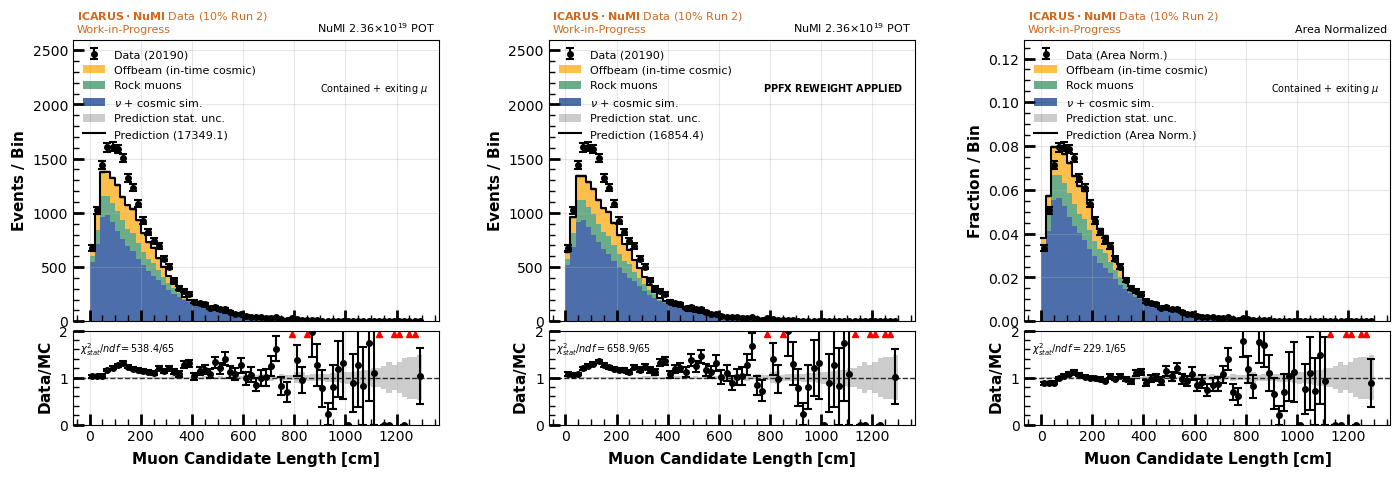


--- preselection_track_length_v5  [Contained + exiting $\mu$] ---
  rows passing mask    : data 26733   mc 571524   rock 2671   offbeam 35396
  plotted (usable reco_leading_muon_length):
    data               : 20190
    prediction no PPFX : 17349.1 +/- 62.1 (stat)
    prediction PPFX    : 16854.4 +/- 61.8 (stat)
    data/MC no PPFX    : 1.1637 +/- 0.0092
    data/MC PPFX       : 1.1979
    chi2_stat/ndf      : no PPFX 538.4/65   PPFX 658.9/65   area 229.1/65
  NO usable reco_leading_muon_length:
    data               : 6543  (24.5% of masked data)
    prediction         : 8519.9 +/- 46.9  (32.9% of masked pred)
    data/MC            : 0.7680 +/- 0.0104
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       1  mc       38  rock        1  offbeam        0
  data reco_leading_muon_length: max 1558.0   99th pct 711.7
  split at reco_leading_muon_length = 400.0:
    below : data    18572   pred   15941.4 +/-  61.0   

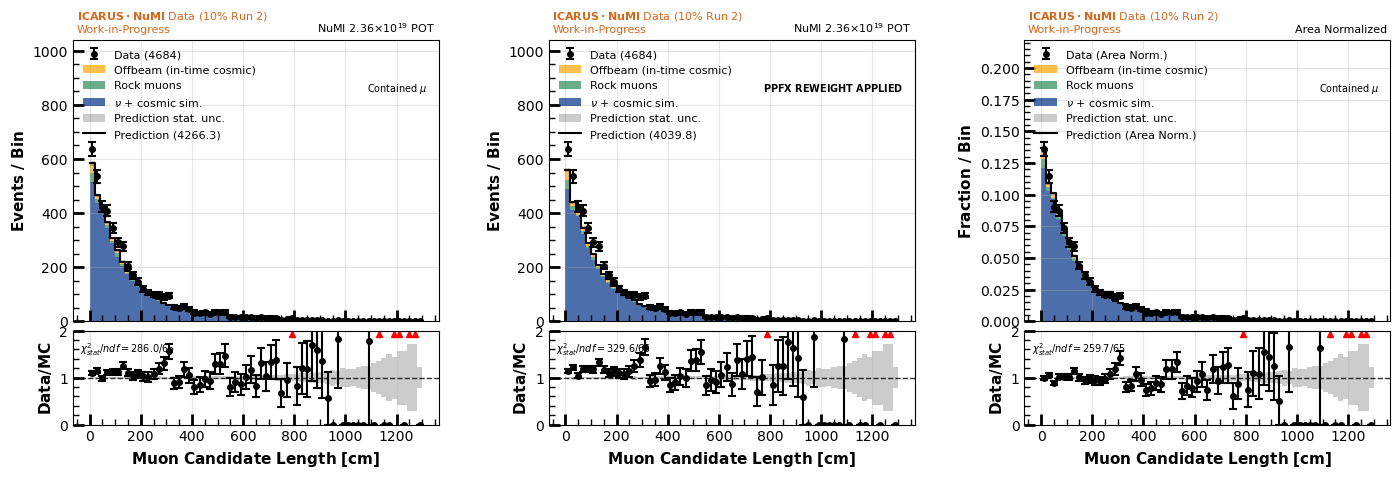


--- preselection_track_length_contained_v5  [Contained $\mu$] ---
  rows passing mask    : data 4684   mc 121706   rock 84   offbeam 1537
  plotted (usable reco_leading_muon_length):
    data               : 4684
    prediction no PPFX : 4266.3 +/- 17.5 (stat)
    prediction PPFX    : 4039.8 +/- 17.1 (stat)
    data/MC no PPFX    : 1.0979 +/- 0.0167
    data/MC PPFX       : 1.1595
    chi2_stat/ndf      : no PPFX 286.0/65   PPFX 329.6/65   area 259.7/65
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc       15  rock        0  offbeam        0
  data reco_leading_muon_length: max 1279.4   99th pct 780.8


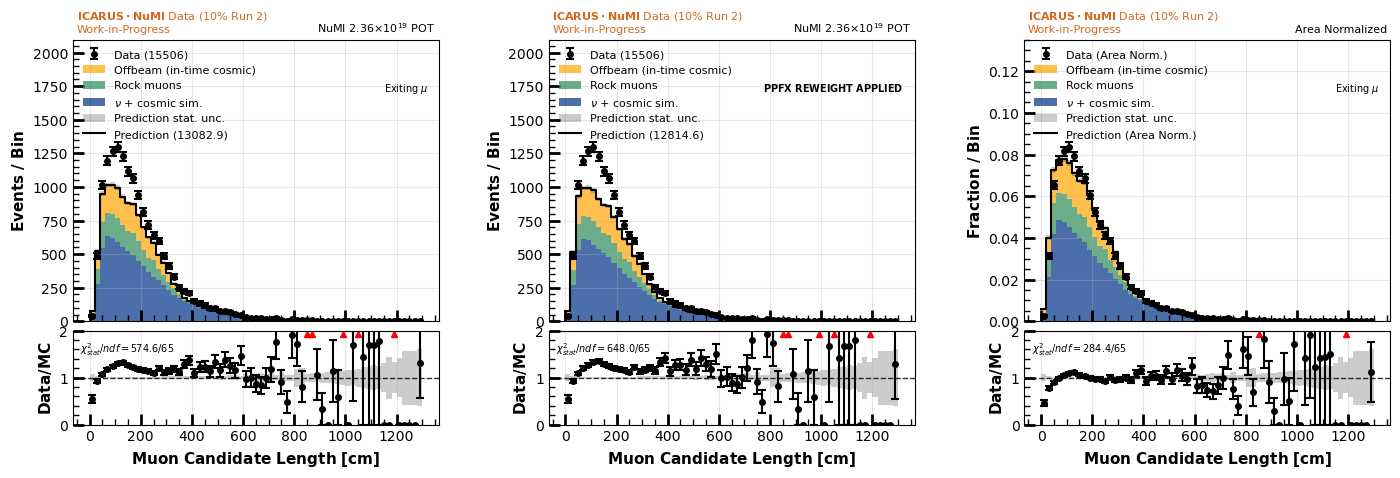


--- preselection_track_length_exiting_v5  [Exiting $\mu$] ---
  rows passing mask    : data 15506   mc 249266   rock 1577   offbeam 28347
  plotted (usable reco_leading_muon_length):
    data               : 15506
    prediction no PPFX : 13082.9 +/- 59.5 (stat)
    prediction PPFX    : 12814.6 +/- 59.4 (stat)
    data/MC no PPFX    : 1.1852 +/- 0.0109
    data/MC PPFX       : 1.2100
    chi2_stat/ndf      : no PPFX 574.6/65   PPFX 648.0/65   area 284.4/65
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       1  mc       23  rock        1  offbeam        0
  data reco_leading_muon_length: max 1558.0   99th pct 682.8

=========== containment decomposition ===========
   contained: data    4684  pred    4266.3  data/MC 1.0979  (data frac 0.232, pred frac 0.246)
     exiting: data   15506  pred   13082.9  data/MC 1.1852  (data frac 0.768, pred frac 0.754)
         sum: data   20190  pred   17349.1  data/MC 1.1637
  cr

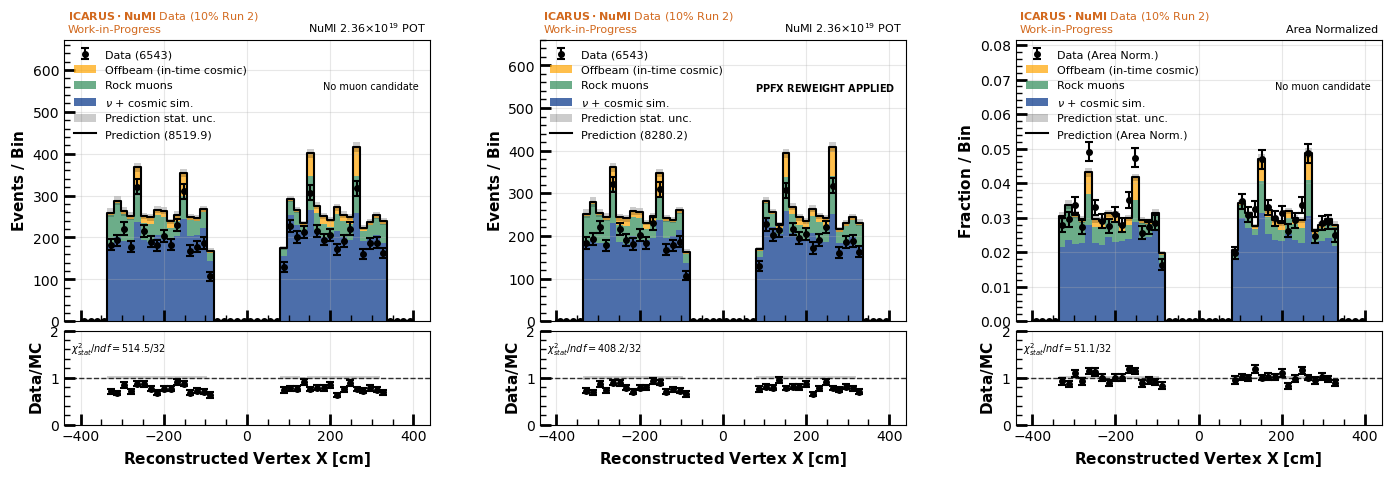


--- presel_nomuon_reco_vertex_x  [No muon candidate] ---
  rows passing mask    : data 6543   mc 200552   rock 1010   offbeam 5512
  plotted (usable reco_vertex_x):
    data               : 6543
    prediction no PPFX : 8519.9 +/- 46.9 (stat)
    prediction PPFX    : 8280.2 +/- 46.7 (stat)
    data/MC no PPFX    : 0.7680 +/- 0.0104
    data/MC PPFX       : 0.7902
    chi2_stat/ndf      : no PPFX 514.5/32   PPFX 408.2/32   area 51.1/32
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_x: max 333.5   99th pct 327.3


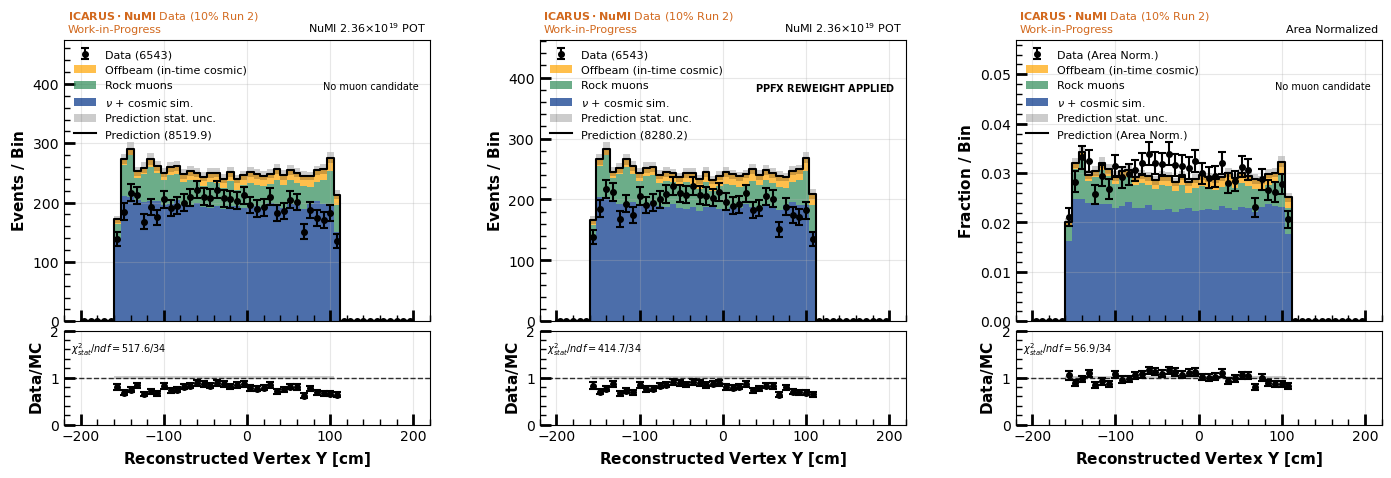


--- presel_nomuon_reco_vertex_y  [No muon candidate] ---
  rows passing mask    : data 6543   mc 200552   rock 1010   offbeam 5512
  plotted (usable reco_vertex_y):
    data               : 6543
    prediction no PPFX : 8519.9 +/- 46.9 (stat)
    prediction PPFX    : 8280.2 +/- 46.7 (stat)
    data/MC no PPFX    : 0.7680 +/- 0.0104
    data/MC PPFX       : 0.7902
    chi2_stat/ndf      : no PPFX 517.6/34   PPFX 414.7/34   area 56.9/34
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_y: max 109.9   99th pct 107.2


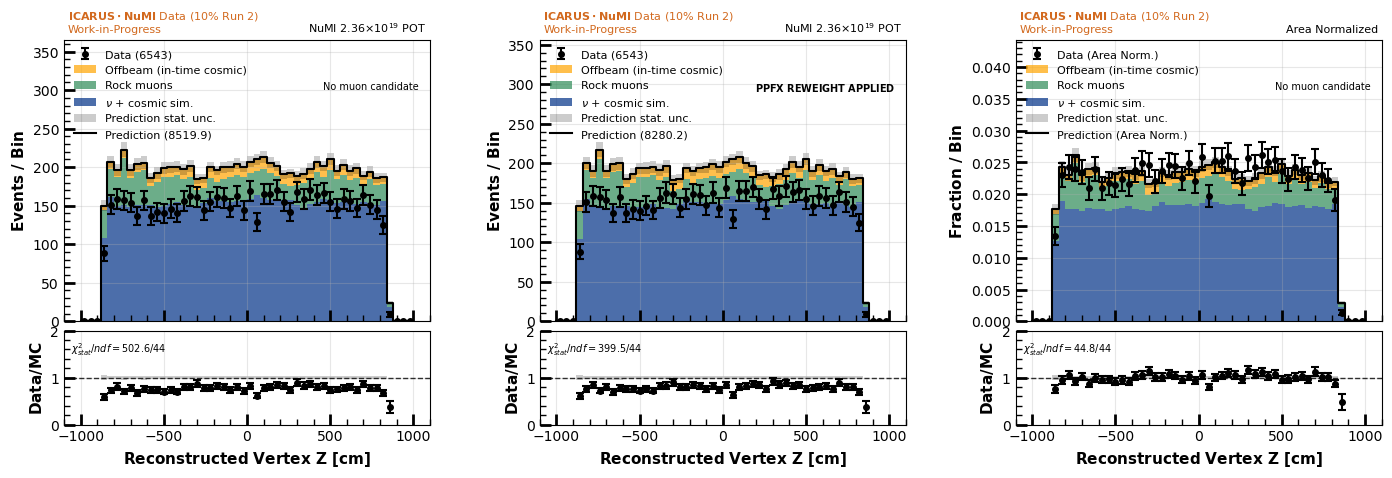


--- presel_nomuon_reco_vertex_z  [No muon candidate] ---
  rows passing mask    : data 6543   mc 200552   rock 1010   offbeam 5512
  plotted (usable reco_vertex_z):
    data               : 6543
    prediction no PPFX : 8519.9 +/- 46.9 (stat)
    prediction PPFX    : 8280.2 +/- 46.7 (stat)
    data/MC no PPFX    : 0.7680 +/- 0.0104
    data/MC PPFX       : 0.7902
    chi2_stat/ndf      : no PPFX 502.6/44   PPFX 399.5/44   area 44.8/44
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_z: max 844.6   99th pct 820.1


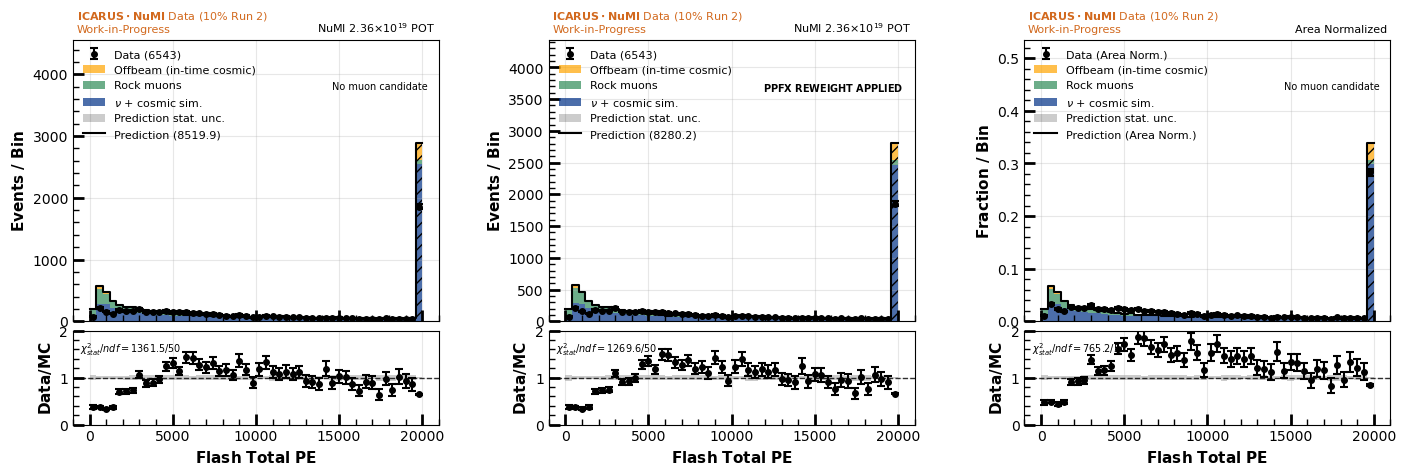


--- presel_nomuon_reco_flash_total_pe  [No muon candidate] ---
  rows passing mask    : data 6543   mc 200552   rock 1010   offbeam 5512
  plotted (usable reco_flash_total_pe):
    data               : 6543
    prediction no PPFX : 8519.9 +/- 46.9 (stat)
    prediction PPFX    : 8280.2 +/- 46.7 (stat)
    data/MC no PPFX    : 0.7680 +/- 0.0104
    data/MC PPFX       : 0.7902
    chi2_stat/ndf      : no PPFX 1361.5/50   PPFX 1269.6/50   area 765.2/50
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data    1811  mc    76188  rock       48  offbeam     2775
  data reco_flash_total_pe: max 227912.7   99th pct 98215.7


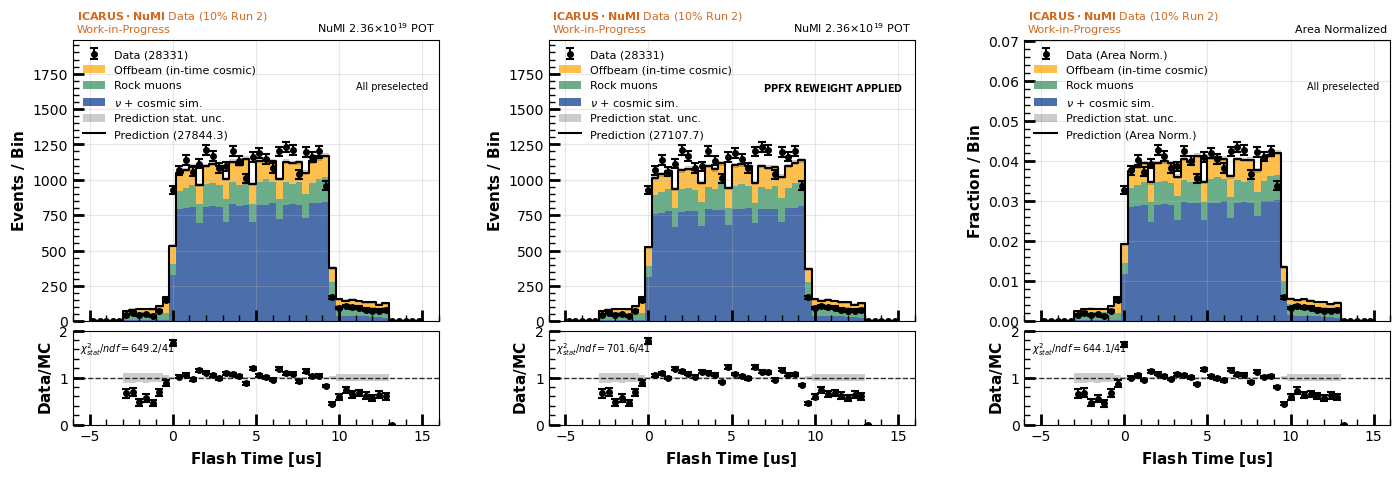


--- preselection_flash_time_v5  [All preselected] ---
  rows passing mask    : data 1129259   mc 19922850   rock 2785031   offbeam 5816828
  plotted (usable reco_flash_time):
    data               : 28331
    prediction no PPFX : 27844.3 +/- 86.6 (stat)
    prediction PPFX    : 27107.7 +/- 86.3 (stat)
    data/MC no PPFX    : 1.0175 +/- 0.0068
    data/MC PPFX       : 1.0451
    chi2_stat/ndf      : no PPFX 649.2/41   PPFX 701.6/41   area 644.1/41
  NO usable reco_flash_time:
    data               : 1100928  (97.5% of masked data)
    prediction         : 5034983.9 +/- 2323.3  (99.5% of masked pred)
    data/MC            : 0.2187 +/- 0.0002
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_flash_time: max 13.0   99th pct 11.6


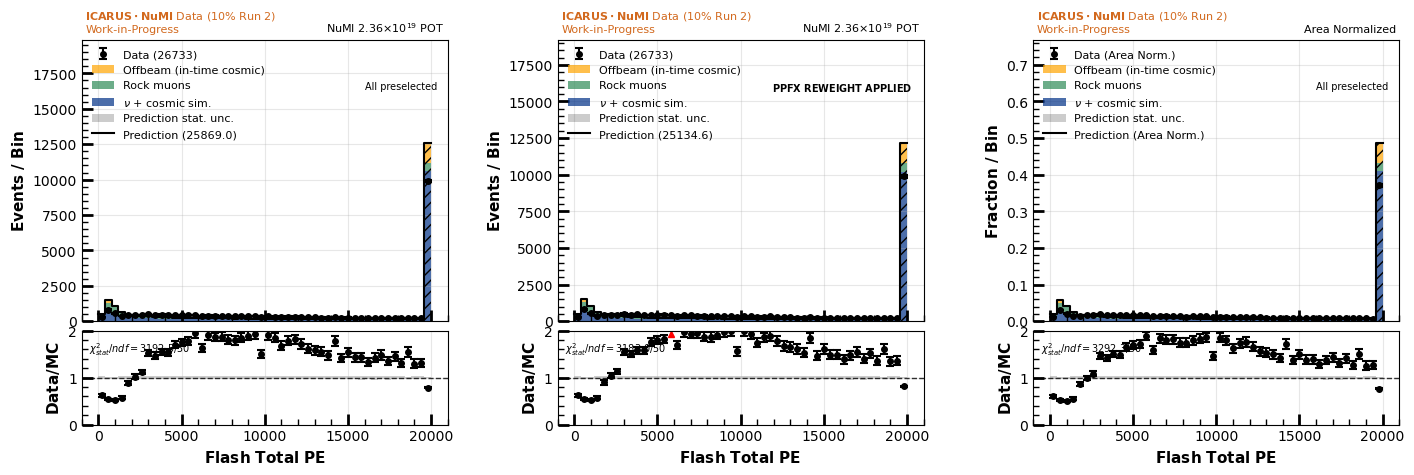


--- preselection_flash_total_pe_v5  [All preselected] ---
  rows passing mask    : data 26733   mc 571524   rock 2671   offbeam 35396
  plotted (usable reco_flash_total_pe):
    data               : 26733
    prediction no PPFX : 25869.0 +/- 77.8 (stat)
    prediction PPFX    : 25134.6 +/- 77.5 (stat)
    data/MC no PPFX    : 1.0334 +/- 0.0070
    data/MC PPFX       : 1.0636
    chi2_stat/ndf      : no PPFX 3192.5/50   PPFX 3183.0/50   area 3292.3/50
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data    9702  mc   319620  rock      406  offbeam    14303
  data reco_flash_total_pe: max 1508864.6   99th pct 91640.1


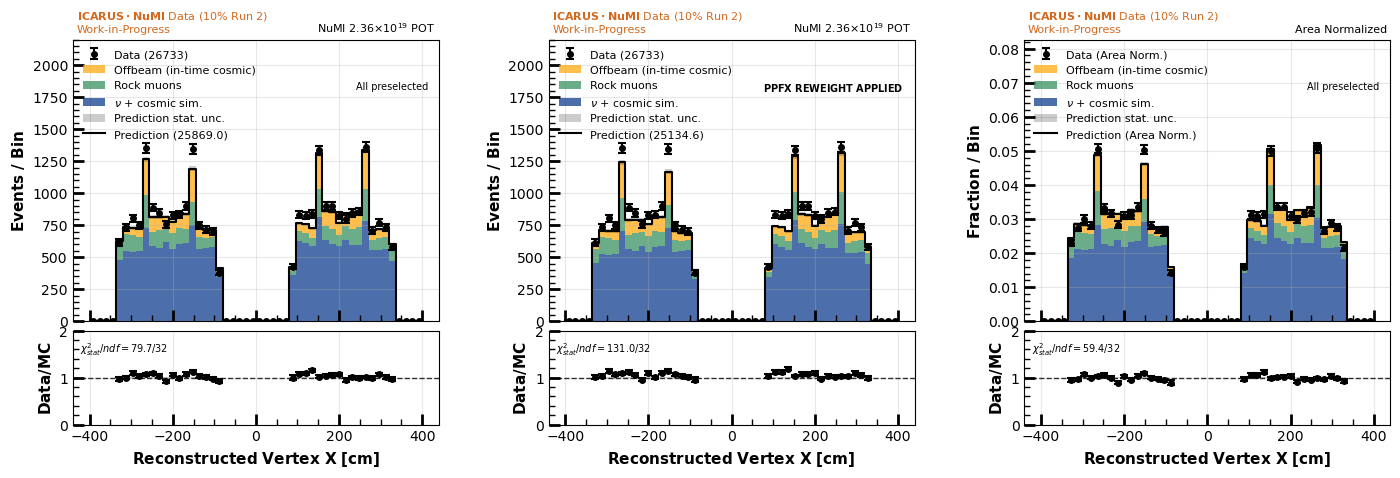


--- preselection_vertex_x_v5  [All preselected] ---
  rows passing mask    : data 26733   mc 571524   rock 2671   offbeam 35396
  plotted (usable reco_vertex_x):
    data               : 26733
    prediction no PPFX : 25869.0 +/- 77.8 (stat)
    prediction PPFX    : 25134.6 +/- 77.5 (stat)
    data/MC no PPFX    : 1.0334 +/- 0.0070
    data/MC PPFX       : 1.0636
    chi2_stat/ndf      : no PPFX 79.7/32   PPFX 131.0/32   area 59.4/32
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_x: max 333.5   99th pct 327.4


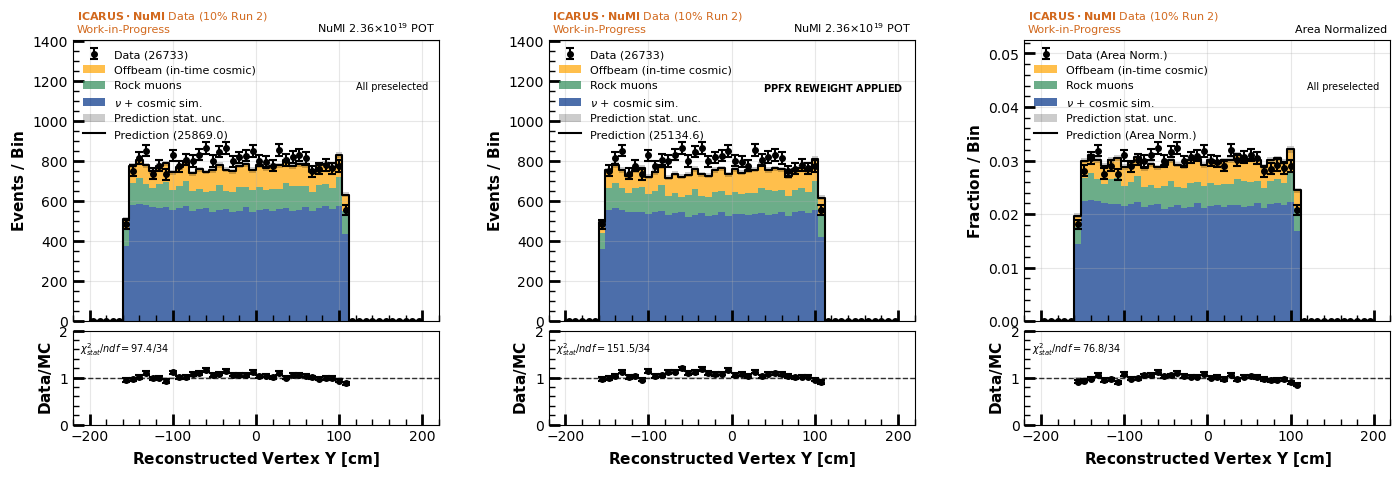


--- preselection_vertex_y_v5  [All preselected] ---
  rows passing mask    : data 26733   mc 571524   rock 2671   offbeam 35396
  plotted (usable reco_vertex_y):
    data               : 26733
    prediction no PPFX : 25869.0 +/- 77.8 (stat)
    prediction PPFX    : 25134.6 +/- 77.5 (stat)
    data/MC no PPFX    : 1.0334 +/- 0.0070
    data/MC PPFX       : 1.0636
    chi2_stat/ndf      : no PPFX 97.4/34   PPFX 151.5/34   area 76.8/34
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_y: max 109.9   99th pct 107.0


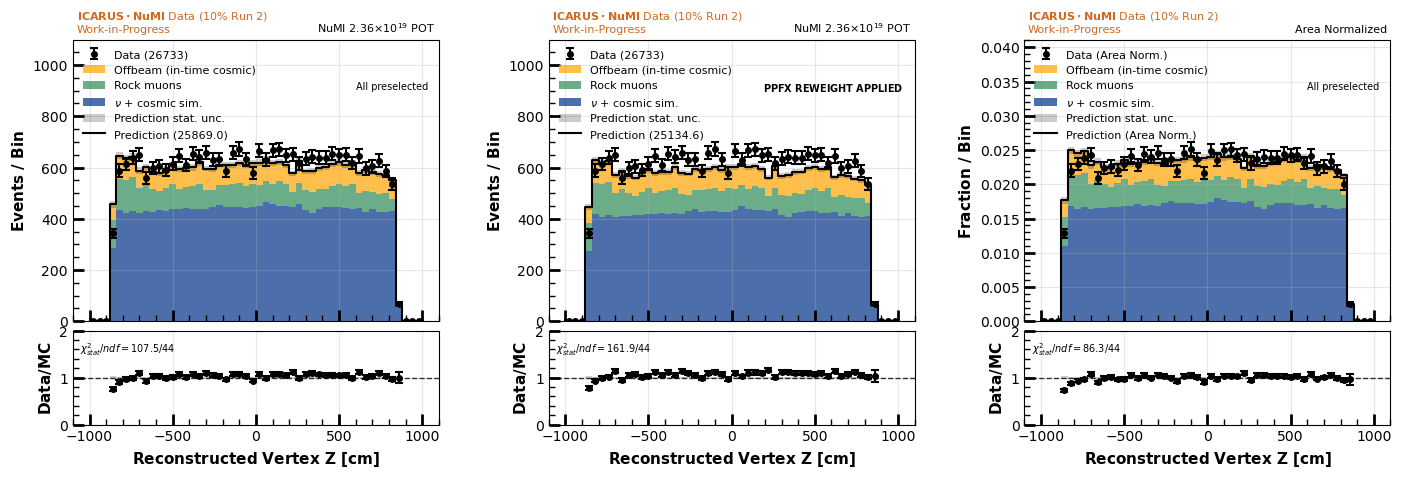


--- preselection_vertex_z_v5  [All preselected] ---
  rows passing mask    : data 26733   mc 571524   rock 2671   offbeam 35396
  plotted (usable reco_vertex_z):
    data               : 26733
    prediction no PPFX : 25869.0 +/- 77.8 (stat)
    prediction PPFX    : 25134.6 +/- 77.5 (stat)
    data/MC no PPFX    : 1.0334 +/- 0.0070
    data/MC PPFX       : 1.0636
    chi2_stat/ndf      : no PPFX 107.5/44   PPFX 161.9/44   area 86.3/44
  folded into edge bins:
    underflow  data       0  mc        0  rock        0  offbeam        0
    overflow   data       0  mc        0  rock        0  offbeam        0
  data reco_vertex_z: max 844.9   99th pct 823.5

Done.


In [7]:
# ============================================================================
# Preselection data/MC plots
#
# Reads the current output file (categories 0-9, per
# selection/toml/1muNp0pi_Nge1_uncontained.toml).
#
# Differences from the original `make_howard_plot`:
#   - under/overflow folded into the edge bins instead of dropped, so the
#     legend integrals are the real sample sizes
#   - entries with no usable value of the plotted variable are counted and
#     reported rather than silently vanishing
#   - the prediction carries a statistical error band (sum w^2 for MC and
#     rock, s_off^2 * N_off for offbeam); statistical only, no systematics
#   - ratio panel shows that band around 1, marks out-of-window bins, and
#     reports a stat-only chi2/ndf
#   - PPFX applied to the nominal MC only (rock muons are not beam flux)
#   - contained / exiting muon split
#
# Self-contained: re-imports and re-defines everything it needs.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

# ------------------------------------------------------------------ config --
# <-- change this one line if the file name is different
DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/1muNp0pi_Nge1_uncontained.root")

FLUX_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "systematics/2025-04-08_out_450.37_7991.98_79512.66.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

MC_SAMPLE          = "nominal"                       # MC directory in the file
CONTAINMENT_BRANCH = "reco_leading_muon_containment"  # 1 = contained, 0 = exiting
MUON_LENGTH_BRANCH = "reco_leading_muon_length"

# Rock muons are not beam-flux neutrinos, so no PPFX reweighting.
APPLY_PPFX_TO_ROCK = False

# Categories, verbatim from selection/toml/1muNp0pi_Nge1_uncontained.toml
CATEGORY_LABELS = {
    0: "Signal, QE",
    1: "Signal, MEC (2p2h)",
    2: "Signal, pion absorption",
    3: "OOFV (signal-like)",
    4: "numuCC Np1pi+-",
    5: "Uncontained muon, fiducial",
    6: "Uncontained muon",
    7: "Neutrino, charged current",
    8: "Neutrino, neutral current",
    9: "Cosmic",
}
SIGNAL_CATEGORIES = {0, 1, 2}

# ------------------------------------------------------------------ style ---
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

# ------------------------------------------------------------------- load ---
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(),    ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()

f = uproot.open(DATA_FILE)


def read_exposure(sample, tree="preselection"):
    """Return (POT, livetime) for a sample.

    Handles both bookkeeping styles: the POT/Livetime histograms used by the
    older files, and the <tree>_exposure trees used by this one. Prints the
    exposure branch names the first time it meets them, so if the branch
    naming is different from what is assumed below it is visible immediately
    rather than silently giving a wrong scale factor.
    """
    pot = lt = None

    # histogram style
    if f"events/{sample}/POT" in f:
        pot = f[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f:
        lt = f[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt

    # tree style
    key = f"events/{sample}/{tree}_exposure"
    if key not in f:
        raise KeyError(f"no exposure information found for sample '{sample}' "
                       f"(looked for events/{sample}/POT, /Livetime and {key})")
    t = f[key]
    print(f"    {sample}/{tree}_exposure branches: {t.keys()}")
    arrays = t.arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt


print("Reading exposures...")
_,        onbeam_lt  = read_exposure("onbeam")
_,        offbeam_lt = read_exposure("offbeam")
rock_pot, _          = read_exposure("rock")

for label, val in (("onbeam livetime", onbeam_lt), ("offbeam livetime", offbeam_lt),
                   ("rock POT", rock_pot)):
    if val is None or not np.isfinite(val) or val <= 0:
        raise ValueError(f"{label} came back as {val}. Check the exposure branch "
                         f"names printed above and adjust read_exposure().")

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"  onbeam livetime  : {onbeam_lt:.4e}")
print(f"  offbeam livetime : {offbeam_lt:.4e}")
print(f"  rock POT         : {rock_pot:.4e}")
print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}")

print("Loading preselection trees...")
mc      = f[f"events/{MC_SAMPLE}/preselection"].arrays(library="pd")
rock    = f["events/rock/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    print(f"  {name:>8}: {len(df)} rows")

seen_cats = sorted(set(int(v) for v in mc["true_category"].values if np.isfinite(v)))
print(f"  true_category values in {MC_SAMPLE}: {seen_cats}")
unknown = [c for c in seen_cats if c not in CATEGORY_LABELS]
if unknown:
    raise ValueError(f"categories {unknown} are not in CATEGORY_LABELS; "
                     f"this file was not produced with the current toml")

HAS_CONTAINMENT = all(CONTAINMENT_BRANCH in df.columns
                      for df in (mc, rock, onbeam, offbeam))
if not HAS_CONTAINMENT:
    print(f"WARNING: '{CONTAINMENT_BRANCH}' missing from at least one sample; "
          f"contained/exiting split will be skipped.")

# --------------------------------------------------------- PPFX weighting ---
def compute_ppfx(df):
    """PPFX CV weight per event, numu/numubar only; everything else stays 1.0.

    Events whose true energy falls outside the weight histogram get 1.0 rather
    than being clipped onto the first/last bin weight, and side='right' puts a
    value sitting exactly on a bin edge into the bin above it.
    """
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))

    for target_pdg, values, edges in ((14, numu_values, numu_edges),
                                      (-14, numubar_values, numubar_edges)):
        m = (pdg == target_pdg) & np.isfinite(nu_e)
        if m.sum() == 0:
            continue
        e = nu_e[m]
        in_hist = (e >= edges[0]) & (e < edges[-1])
        idx = np.clip(np.searchsorted(edges, e, side='right') - 1, 0, len(values) - 1)
        w[np.where(m)[0]] = np.where(in_hist, values[idx], 1.0)
    return w

mc["ppfx_weight"] = compute_ppfx(mc)
rock["ppfx_weight"] = compute_ppfx(rock) if APPLY_PPFX_TO_ROCK else np.ones(len(rock))
print(f"Mean PPFX weight ({MC_SAMPLE}, whole tree): {mc['ppfx_weight'].mean():.4f}   "
      f"rock reweighted: {APPLY_PPFX_TO_ROCK}")

# --------------------------------------------------------------- helpers ---
def _hist_with_overflow(values, weights, bins, valid=None):
    """np.histogram with under/overflow folded into the edge bins.

    `valid` optionally marks physically meaningful entries, so sentinel values
    (e.g. reco_flash_total_pe < 0 meaning "no flash") are counted as "no
    measurement" rather than as underflow.
    """
    values  = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    good = np.isfinite(values)
    if valid is not None:
        good &= np.asarray(valid, dtype=bool)

    v, w = values[good], weights[good]
    n_bad = int((~good).sum())
    sumw_bad, sumw2_bad = weights[~good].sum(), (weights[~good] ** 2).sum()

    n_under = int((v < bins[0]).sum())
    n_over  = int((v > bins[-1]).sum())

    v = np.clip(v, bins[0], np.nextafter(bins[-1], bins[0]))
    sumw,  _ = np.histogram(v, bins=bins, weights=w)
    sumw2, _ = np.histogram(v, bins=bins, weights=w * w)

    return dict(sumw=sumw, sumw2=sumw2, n_under=n_under, n_over=n_over,
                n_good=int(good.sum()), n_bad=n_bad,
                sumw_bad=sumw_bad, sumw2_bad=sumw2_bad)


def _ratio_err(d, p, pe):
    """Statistical error on data/prediction: Poisson data + weighted MC."""
    if p <= 0:
        return np.nan
    return (d / p) * np.sqrt(1.0 / max(d, 1.0) + (pe / p) ** 2)


# --------------------------------------------------------------- plotting ---
def make_preselection_plot(variable, xlabel, bins, output_name,
                           require_flash_match=False,
                           mask_expr=None, mask_fn=None, mask_label=None,
                           valid_fn=None, split_value=None):
    """Three-panel data/MC comparison: no PPFX | PPFX | area normalised."""
    bins = np.asarray(bins, dtype=float)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    def build_mask(df):
        m = np.ones(len(df), dtype=bool)
        if require_flash_match:
            m &= (df["reco_flash_time"] > 0.0) & (df["reco_flash_time"] < 9.6)
        if mask_expr is not None:
            m &= df.eval(mask_expr).values
        if mask_fn is not None:
            m &= np.asarray(mask_fn(df), dtype=bool)
        return m

    m_mc, m_rock = build_mask(mc), build_mask(rock)
    m_off, m_on  = build_mask(offbeam), build_mask(onbeam)

    v_mc   = mc.loc[m_mc,       variable].values
    v_rock = rock.loc[m_rock,   variable].values
    v_off  = offbeam.loc[m_off, variable].values
    v_on   = onbeam.loc[m_on,   variable].values

    vf = (lambda v: valid_fn(v)) if valid_fn is not None else (lambda v: None)

    h_mc_nop = _hist_with_overflow(v_mc,  np.full(len(v_mc), mc_scale), bins, vf(v_mc))
    h_mc_ppf = _hist_with_overflow(v_mc,  mc.loc[m_mc, "ppfx_weight"].values * mc_scale, bins, vf(v_mc))
    h_rk     = _hist_with_overflow(v_rock, np.full(len(v_rock), rock_scale), bins, vf(v_rock))
    h_rk_ppf = _hist_with_overflow(v_rock, rock.loc[m_rock, "ppfx_weight"].values * rock_scale, bins, vf(v_rock))
    h_off    = _hist_with_overflow(v_off, np.ones(len(v_off)), bins, vf(v_off))
    h_dat    = _hist_with_overflow(v_on,  np.ones(len(v_on)),  bins, vf(v_on))

    mc_nop, rk_nop = h_mc_nop['sumw'], h_rk['sumw']
    mc_ppf, rk_ppf = h_mc_ppf['sumw'], h_rk_ppf['sumw']
    off     = h_off['sumw'] * offbeam_scale
    off_var = h_off['sumw'] * offbeam_scale ** 2     # Poisson on raw counts, then scaled
    dat     = h_dat['sumw']
    dat_err = np.sqrt(dat)

    pred_nop = mc_nop + rk_nop + off
    pred_ppf = mc_ppf + rk_ppf + off
    err_nop  = np.sqrt(h_mc_nop['sumw2'] + h_rk['sumw2']     + off_var)
    err_ppf  = np.sqrt(h_mc_ppf['sumw2'] + h_rk_ppf['sumw2'] + off_var)

    n_data = int(dat.sum())
    n_data_novalue = h_dat['n_bad']
    pred_novalue   = (h_mc_nop['sumw_bad'] + h_rk['sumw_bad']
                      + h_off['sumw_bad'] * offbeam_scale)
    pred_novalue_e = np.sqrt(h_mc_nop['sumw2_bad'] + h_rk['sumw2_bad']
                             + h_off['sumw_bad'] * offbeam_scale ** 2)

    tot_p = pred_nop.sum()
    mc_a, rk_a, off_a = mc_nop / tot_p, rk_nop / tot_p, off / tot_p
    pred_a, err_a     = pred_nop / tot_p, err_nop / tot_p
    dat_a, dat_a_err  = dat / n_data, dat_err / n_data

    u_tot = h_mc_nop['n_under'] + h_rk['n_under'] + h_off['n_under'] + h_dat['n_under']
    o_tot = h_mc_nop['n_over']  + h_rk['n_over']  + h_off['n_over']  + h_dat['n_over']

    fig = plt.figure(figsize=(17, 5))
    gs  = gridspec.GridSpec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.3)
    tops = [fig.add_subplot(gs[0, i]) for i in range(3)]
    bots = [fig.add_subplot(gs[1, i], sharex=tops[i]) for i in range(3)]

    def draw_panel(ax, mcv, rkv, offv, predv, prederr, dv, derr,
                   ylabel, pot_str, corner=None, show_counts=True):
        bot = np.zeros(len(bins) - 1)
        ax.bar(bin_centers, mcv,  width=bin_width, bottom=bot, color="#003087",
               alpha=0.7, label=r"$\nu$ + cosmic sim.")
        bot = bot + mcv
        ax.bar(bin_centers, rkv,  width=bin_width, bottom=bot, color="seagreen",
               alpha=0.7, label="Rock muons")
        bot = bot + rkv
        ax.bar(bin_centers, offv, width=bin_width, bottom=bot, color="orange",
               alpha=0.7, label="Offbeam (in-time cosmic)")

        for j, n_extra in ((0, u_tot), (len(bins) - 2, o_tot)):
            if n_extra > 0:
                ax.bar(bin_centers[j], bot[j] + offv[j], width=bin_width[j],
                       fill=False, edgecolor='black', hatch='///',
                       linewidth=0.0, zorder=4)

        ax.step(np.append(bins[:-1], bins[-1]), np.append(predv, predv[-1]),
                where='post', color='black', linewidth=1.5,
                label=(f"Prediction ({predv.sum():.1f})" if show_counts
                       else "Prediction (Area Norm.)"))
        ax.fill_between(np.append(bins[:-1], bins[-1]),
                        np.append(predv - prederr, (predv - prederr)[-1]),
                        np.append(predv + prederr, (predv + prederr)[-1]),
                        step='post', color='black', alpha=0.20, linewidth=0,
                        label="Prediction stat. unc.")
        ax.errorbar(bin_centers, dv, yerr=derr, fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                    label=(f"Data ({n_data})" if show_counts else "Data (Area Norm.)"),
                    zorder=5)

        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
        h, l = ax.get_legend_handles_labels()
        ax.legend(h[::-1], l[::-1], fontsize=8, loc='upper left',
                  framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str)
        if corner:
            add_corner_label(ax, corner)

    def draw_ratio(ax, predv, prederr, dv, derr):
        with np.errstate(invalid="ignore", divide="ignore"):
            r    = np.where(predv > 0, dv / predv, np.nan)
            rerr = np.where(predv > 0, derr / predv, np.nan)
            band = np.where(predv > 0, prederr / predv, np.nan)

        ax.fill_between(np.append(bins[:-1], bins[-1]),
                        np.append(1 - band, (1 - band)[-1]),
                        np.append(1 + band, (1 + band)[-1]),
                        step='post', color='black', alpha=0.20, linewidth=0)

        inside = np.isfinite(r) & (r >= 0.0) & (r <= 2.0)
        ax.errorbar(bin_centers[inside], r[inside], yerr=rerr[inside],
                    fmt='o', markersize=4, markerfacecolor='black',
                    markeredgecolor='black', color='black',
                    capsize=3, capthick=1.5, elinewidth=1.5)
        hi = np.isfinite(r) & (r > 2.0)
        if hi.any():
            ax.plot(bin_centers[hi], np.full(hi.sum(), 1.92), marker='^',
                    linestyle='none', markersize=5, color='red')

        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

        good = (predv > 0) & (derr ** 2 + prederr ** 2 > 0)
        chi2 = np.sum((dv[good] - predv[good]) ** 2 / (derr[good] ** 2 + prederr[good] ** 2))
        ndf = int(good.sum())
        ax.text(0.02, 0.90, rf"$\chi^2_{{stat}}/ndf = {chi2:.1f}/{ndf}$",
                transform=ax.transAxes, fontsize=7, va='top', fontfamily="sans-serif")
        return chi2, ndf

    pot_str = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"
    sel_txt = mask_label if mask_label else "All preselected"

    draw_panel(tops[0], mc_nop, rk_nop, off, pred_nop, err_nop, dat, dat_err,
               r"$\mathbf{Events\ /\ Bin}$", pot_str, corner=sel_txt)
    c0 = draw_ratio(bots[0], pred_nop, err_nop, dat, dat_err)

    draw_panel(tops[1], mc_ppf, rk_ppf, off, pred_ppf, err_ppf, dat, dat_err,
               r"$\mathbf{Events\ /\ Bin}$", pot_str,
               corner=r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$')
    c1 = draw_ratio(bots[1], pred_ppf, err_ppf, dat, dat_err)

    draw_panel(tops[2], mc_a, rk_a, off_a, pred_a, err_a, dat_a, dat_a_err,
               r"$\mathbf{Fraction\ /\ Bin}$", "Area Normalized",
               corner=sel_txt, show_counts=False)
    c2 = draw_ratio(bots[2], pred_a, err_a, dat_a, dat_a_err)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),  bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    print(f"\n--- {output_name}  [{sel_txt}] ---")
    print(f"  rows passing mask    : data {int(m_on.sum())}   mc {int(m_mc.sum())}   "
          f"rock {int(m_rock.sum())}   offbeam {int(m_off.sum())}")
    print(f"  plotted (usable {variable}):")
    print(f"    data               : {n_data}")
    print(f"    prediction no PPFX : {pred_nop.sum():.1f} +/- {np.sqrt((err_nop**2).sum()):.1f} (stat)")
    print(f"    prediction PPFX    : {pred_ppf.sum():.1f} +/- {np.sqrt((err_ppf**2).sum()):.1f} (stat)")
    print(f"    data/MC no PPFX    : {n_data/pred_nop.sum():.4f} +/- "
          f"{_ratio_err(n_data, pred_nop.sum(), np.sqrt((err_nop**2).sum())):.4f}")
    print(f"    data/MC PPFX       : {n_data/pred_ppf.sum():.4f}")
    print(f"    chi2_stat/ndf      : no PPFX {c0[0]:.1f}/{c0[1]}   "
          f"PPFX {c1[0]:.1f}/{c1[1]}   area {c2[0]:.1f}/{c2[1]}")
    if n_data_novalue > 0 or pred_novalue > 0:
        frac_d = n_data_novalue / max(int(m_on.sum()), 1)
        frac_p = pred_novalue / max(pred_nop.sum() + pred_novalue, 1e-9)
        print(f"  NO usable {variable}:")
        print(f"    data               : {n_data_novalue}  ({frac_d:.1%} of masked data)")
        print(f"    prediction         : {pred_novalue:.1f} +/- {pred_novalue_e:.1f}  ({frac_p:.1%} of masked pred)")
        if pred_novalue > 0:
            print(f"    data/MC            : {n_data_novalue/pred_novalue:.4f} +/- "
                  f"{_ratio_err(n_data_novalue, pred_novalue, pred_novalue_e):.4f}")
    print(f"  folded into edge bins:")
    print(f"    underflow  data {h_dat['n_under']:7d}  mc {h_mc_nop['n_under']:8d}  "
          f"rock {h_rk['n_under']:8d}  offbeam {h_off['n_under']:8d}")
    print(f"    overflow   data {h_dat['n_over']:7d}  mc {h_mc_nop['n_over']:8d}  "
          f"rock {h_rk['n_over']:8d}  offbeam {h_off['n_over']:8d}")
    if h_dat['n_good'] > 0:
        usable = v_on[np.isfinite(v_on)]
        if valid_fn is not None:
            usable = usable[valid_fn(usable)]
        if len(usable):
            print(f"  data {variable}: max {np.max(usable):.1f}   "
                  f"99th pct {np.percentile(usable, 99):.1f}")

    if split_value is not None:
        def counts(v, w):
            v = np.asarray(v, dtype=float)
            ok = np.isfinite(v)
            if valid_fn is not None:
                ok &= valid_fn(v)
            v, w = v[ok], np.asarray(w, dtype=float)[ok]
            lo = v < split_value
            return w[lo].sum(), (w[lo] ** 2).sum(), w[~lo].sum(), (w[~lo] ** 2).sum()

        d_lo, _, d_hi, _         = counts(v_on,   np.ones(len(v_on)))
        m_lo, m_lo2, m_hi, m_hi2 = counts(v_mc,   np.full(len(v_mc), mc_scale))
        r_lo, r_lo2, r_hi, r_hi2 = counts(v_rock, np.full(len(v_rock), rock_scale))
        o_lo, o_lo2, o_hi, o_hi2 = counts(v_off,  np.full(len(v_off), offbeam_scale))
        p_lo, p_hi   = m_lo + r_lo + o_lo, m_hi + r_hi + o_hi
        pe_lo, pe_hi = np.sqrt(m_lo2 + r_lo2 + o_lo2), np.sqrt(m_hi2 + r_hi2 + o_hi2)
        print(f"  split at {variable} = {split_value}:")
        print(f"    below : data {d_lo:8.0f}   pred {p_lo:9.1f} +/- {pe_lo:5.1f}   "
              f"ratio {d_lo/p_lo:.3f} +/- {_ratio_err(d_lo, p_lo, pe_lo):.3f}")
        print(f"    above : data {d_hi:8.0f}   pred {p_hi:9.1f} +/- {pe_hi:5.1f}   "
              f"ratio {d_hi/p_hi:.3f} +/- {_ratio_err(d_hi, p_hi, pe_hi):.3f}")

    return dict(n_data=n_data, pred_nop=pred_nop.sum(), pred_ppf=pred_ppf.sum(),
                n_data_novalue=n_data_novalue, pred_novalue=pred_novalue,
                n_masked_data=int(m_on.sum()))


# ============================================================================
# 1. Muon candidate length, then split by muon containment
# ============================================================================
LEN_BINS = np.linspace(0, 1300, 66)

results = {}
results['all'] = make_preselection_plot(
    MUON_LENGTH_BRANCH, "Muon Candidate Length [cm]", LEN_BINS,
    "preselection_track_length_v5", require_flash_match=True,
    mask_label="Contained + exiting $\\mu$", split_value=400.0)

if HAS_CONTAINMENT:
    results['contained'] = make_preselection_plot(
        MUON_LENGTH_BRANCH, "Muon Candidate Length [cm]", LEN_BINS,
        "preselection_track_length_contained_v5", require_flash_match=True,
        mask_expr=f"{CONTAINMENT_BRANCH} == 1", mask_label="Contained $\\mu$")

    results['exiting'] = make_preselection_plot(
        MUON_LENGTH_BRANCH, "Muon Candidate Length [cm]", LEN_BINS,
        "preselection_track_length_exiting_v5", require_flash_match=True,
        mask_expr=f"{CONTAINMENT_BRANCH} == 0", mask_label="Exiting $\\mu$")

    print("\n=========== containment decomposition ===========")
    tot_d = sum(results[k]['n_data']   for k in ('contained', 'exiting'))
    tot_p = sum(results[k]['pred_nop'] for k in ('contained', 'exiting'))
    for k in ('contained', 'exiting'):
        r = results[k]
        print(f"  {k:>10}: data {r['n_data']:7d}  pred {r['pred_nop']:9.1f}  "
              f"data/MC {r['n_data']/r['pred_nop']:.4f}  "
              f"(data frac {r['n_data']/tot_d:.3f}, pred frac {r['pred_nop']/tot_p:.3f})")
    print(f"  {'sum':>10}: data {tot_d:7d}  pred {tot_p:9.1f}  data/MC {tot_d/tot_p:.4f}")
    print(f"  cross-check vs 'all': data {results['all']['n_data']}  "
          f"pred {results['all']['pred_nop']:.1f}")


# ============================================================================
# 2. Events with no muon candidate
# ============================================================================
print("\n=========== 'no muon candidate' diagnostic ===========")

def no_muon(df):   return ~np.isfinite(df[MUON_LENGTH_BRANCH].values)
def has_muon(df):  return np.isfinite(df[MUON_LENGTH_BRANCH].values)
def flash_matched(df):
    return (df["reco_flash_time"] > 0.0) & (df["reco_flash_time"] < 9.6)

rows = []
for label, fn in (("with muon cand.", has_muon), ("no muon cand.", no_muon)):
    d = int((flash_matched(onbeam) & fn(onbeam)).sum())
    n_mc  = (flash_matched(mc)      & fn(mc)).sum()
    n_rk  = (flash_matched(rock)    & fn(rock)).sum()
    n_off = (flash_matched(offbeam) & fn(offbeam)).sum()
    p_mc, p_rk, p_off = n_mc * mc_scale, n_rk * rock_scale, n_off * offbeam_scale
    p  = p_mc + p_rk + p_off
    pe = np.sqrt(n_mc * mc_scale**2 + n_rk * rock_scale**2 + n_off * offbeam_scale**2)
    rows.append((label, d, p, pe, p_mc, p_rk, p_off))

print(f"  {'subset':>16} {'data':>8} {'pred':>10} {'data/MC':>18}"
      f" | {'nu+cos':>9} {'rock':>9} {'offbeam':>9}")
for label, d, p, pe, p_mc, p_rk, p_off in rows:
    print(f"  {label:>16} {d:8d} {p:10.1f} {d/p:8.4f} +/- {_ratio_err(d, p, pe):.4f}"
          f" | {p_mc:9.1f} {p_rk:9.1f} {p_off:9.1f}")
tot_d, tot_p = sum(r[1] for r in rows), sum(r[2] for r in rows)
print(f"  {'TOTAL':>16} {tot_d:8d} {tot_p:10.1f} {tot_d/tot_p:8.4f}")

# --- MC composition of each subset --------------------------------------
sel_with = flash_matched(mc) & has_muon(mc)
sel_no   = flash_matched(mc) & no_muon(mc)
cat_vals = mc["true_category"].values

print(f"\n  {MC_SAMPLE} true_category composition (flash-matched, POT-scaled):")
print(f"  {'cat':>4} {'label':>28} {'with muon':>12} {'no muon':>12} {'no-mu frac':>11}")
per_cat = {}
for c in sorted(CATEGORY_LABELS):
    cc  = cat_vals == c
    n_w = (sel_with & cc).sum() * mc_scale
    n_n = (sel_no   & cc).sum() * mc_scale
    per_cat[c] = (n_w, n_n)
    if n_w + n_n > 0:
        print(f"  {c:>4} {CATEGORY_LABELS[c]:>28} {n_w:12.1f} {n_n:12.1f} "
              f"{n_n/(n_w+n_n):10.1%}")

nan_w = (sel_with & ~np.isfinite(cat_vals)).sum() * mc_scale
nan_n = (sel_no   & ~np.isfinite(cat_vals)).sum() * mc_scale
if nan_w + nan_n > 0:
    print(f"  {'--':>4} {'(no category / NaN)':>28} {nan_w:12.1f} {nan_n:12.1f}")

sig_w = sum(per_cat[c][0] for c in SIGNAL_CATEGORIES)
sig_n = sum(per_cat[c][1] for c in SIGNAL_CATEGORIES)
print(f"\n  signal (cats {sorted(SIGNAL_CATEGORIES)}): with muon {sig_w:.1f}, no muon {sig_n:.1f}")
print(f"  signal purity of the with-muon prediction: {sig_w:.1f} / "
      f"{results['all']['pred_nop']:.1f} = {sig_w/results['all']['pred_nop']:.1%}")

# --- where the no-muon events sit ---------------------------------------
for var, lab, bns, vfn in (
        ("reco_vertex_x", "Reconstructed Vertex X [cm]", np.linspace(-400, 400, 51), None),
        ("reco_vertex_y", "Reconstructed Vertex Y [cm]", np.linspace(-200, 200, 51), None),
        ("reco_vertex_z", "Reconstructed Vertex Z [cm]", np.linspace(-1000, 1000, 51), None),
        ("reco_flash_total_pe", "Flash Total PE", np.linspace(0, 20000, 51), lambda v: v >= 0)):
    make_preselection_plot(var, lab, bns, f"presel_nomuon_{var}",
                           require_flash_match=True, mask_fn=no_muon,
                           mask_label="No muon candidate", valid_fn=vfn)


# ============================================================================
# 3. The other preselection variables
# ============================================================================
make_preselection_plot("reco_flash_time", "Flash Time [us]",
                       np.linspace(-5, 15, 51), "preselection_flash_time_v5")

make_preselection_plot("reco_flash_total_pe", "Flash Total PE",
                       np.linspace(0, 20000, 51), "preselection_flash_total_pe_v5",
                       require_flash_match=True, valid_fn=lambda v: v >= 0)

make_preselection_plot("reco_vertex_x", "Reconstructed Vertex X [cm]",
                       np.linspace(-400, 400, 51), "preselection_vertex_x_v5",
                       require_flash_match=True)

make_preselection_plot("reco_vertex_y", "Reconstructed Vertex Y [cm]",
                       np.linspace(-200, 200, 51), "preselection_vertex_y_v5",
                       require_flash_match=True)

make_preselection_plot("reco_vertex_z", "Reconstructed Vertex Z [cm]",
                       np.linspace(-1000, 1000, 51), "preselection_vertex_z_v5",
                       require_flash_match=True)

print("\nDone.")


MC scale:      3.2896e-02
Offbeam scale: 9.5295e-02
Rock scale:    1.3835e+00  (rock POT = 1.7067e+19)
Loading preselection trees...
Mean PPFX weight (nominal): 0.9984


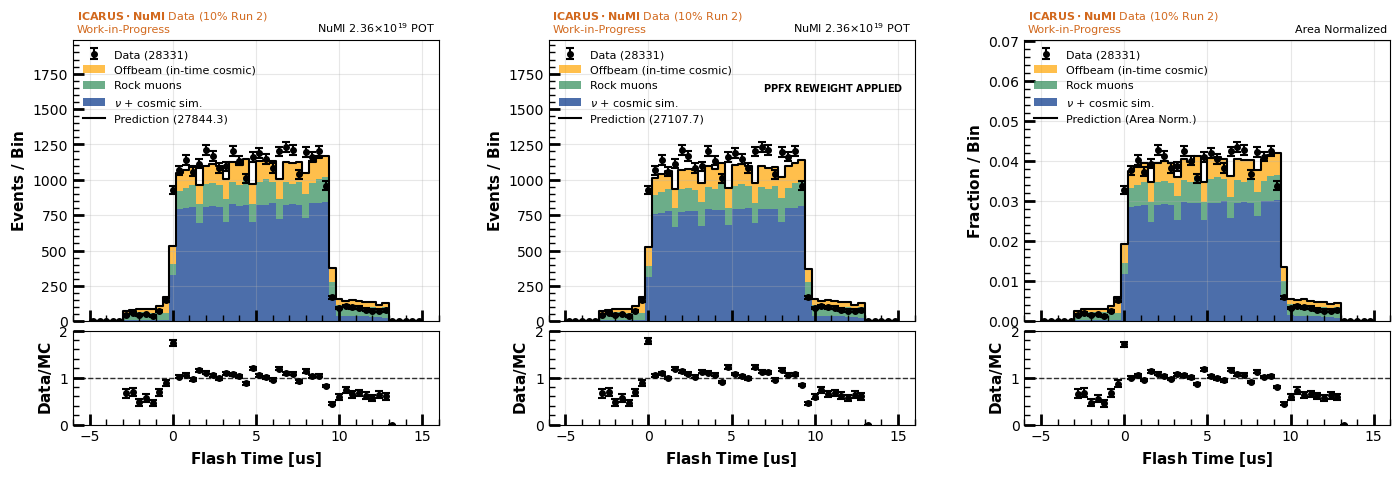

Saved: preselection_flash_time  (data 28331, pred 27844.3, ratio 1.017)


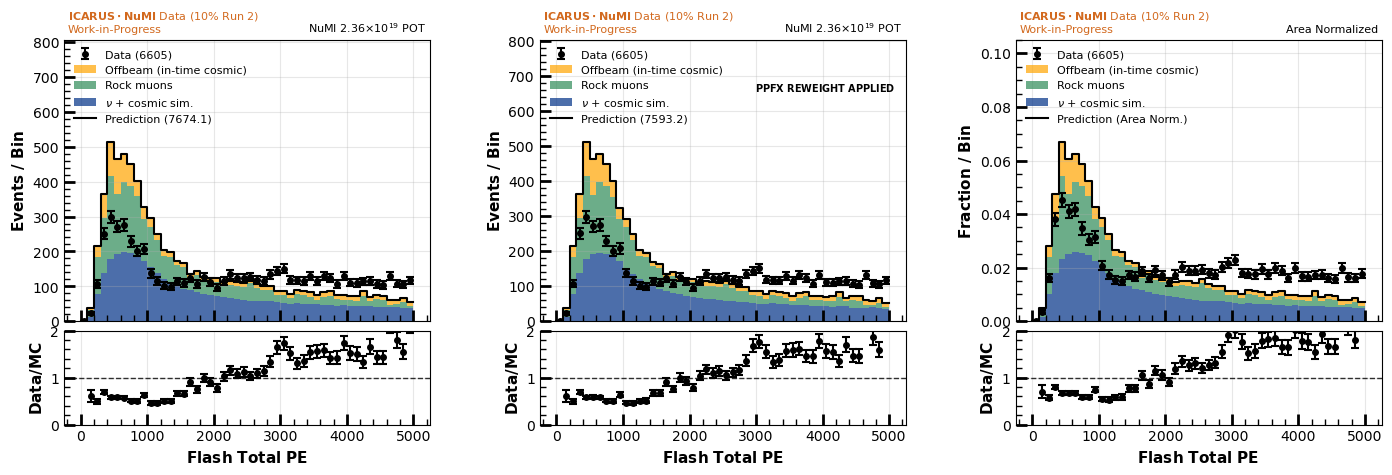

Saved: preselection_flash_total_pe  (data 6605, pred 7674.1, ratio 0.861)


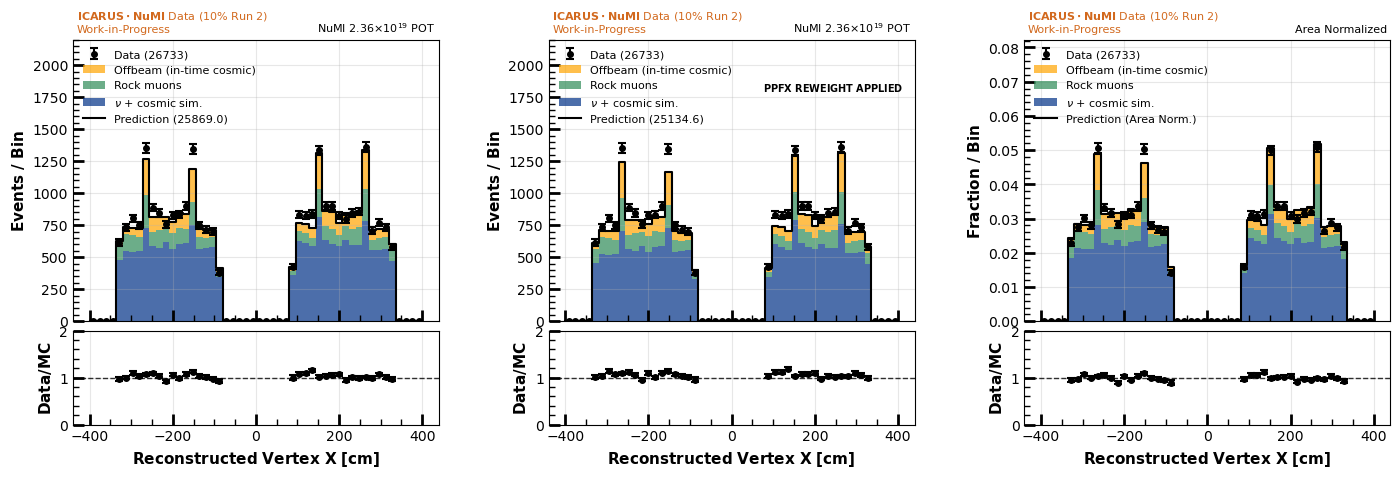

Saved: preselection_vertex_x  (data 26733, pred 25869.0, ratio 1.033)


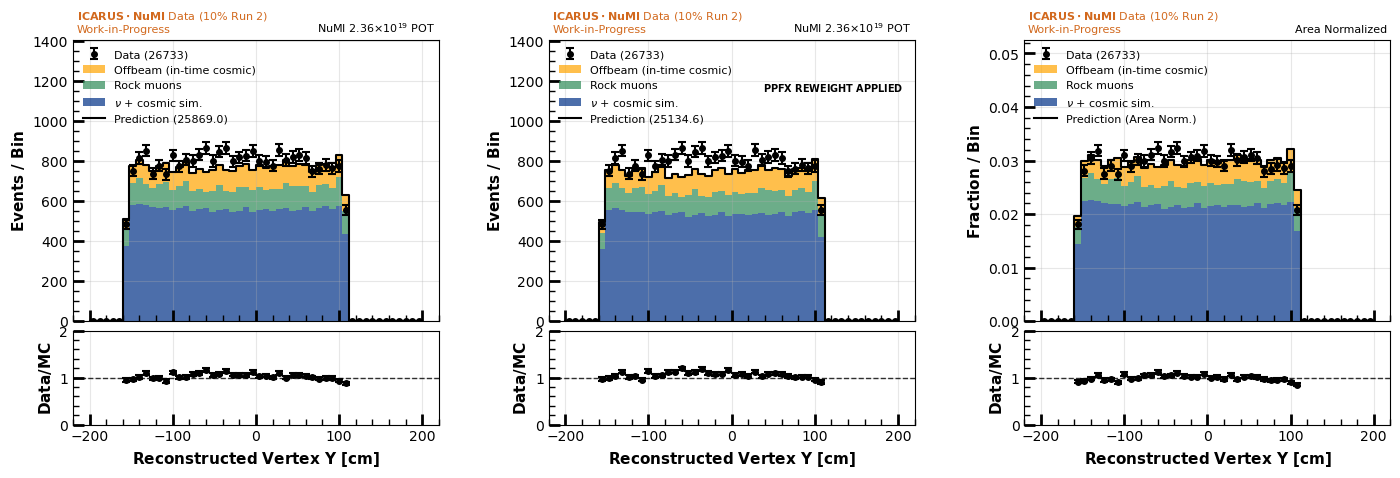

Saved: preselection_vertex_y  (data 26733, pred 25869.0, ratio 1.033)


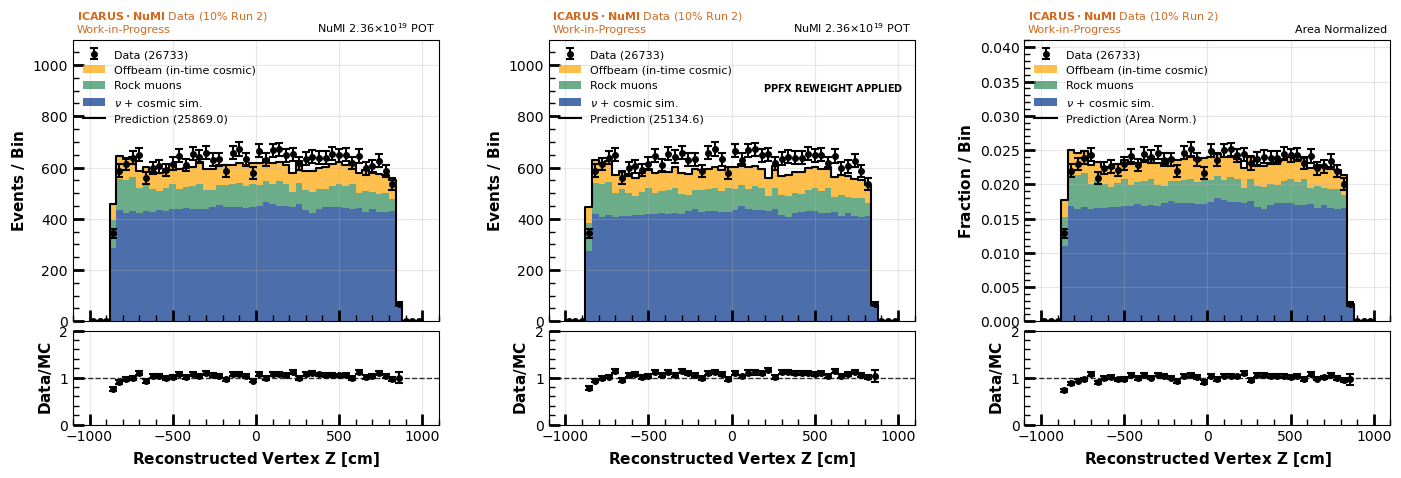

Saved: preselection_vertex_z  (data 26733, pred 25869.0, ratio 1.033)


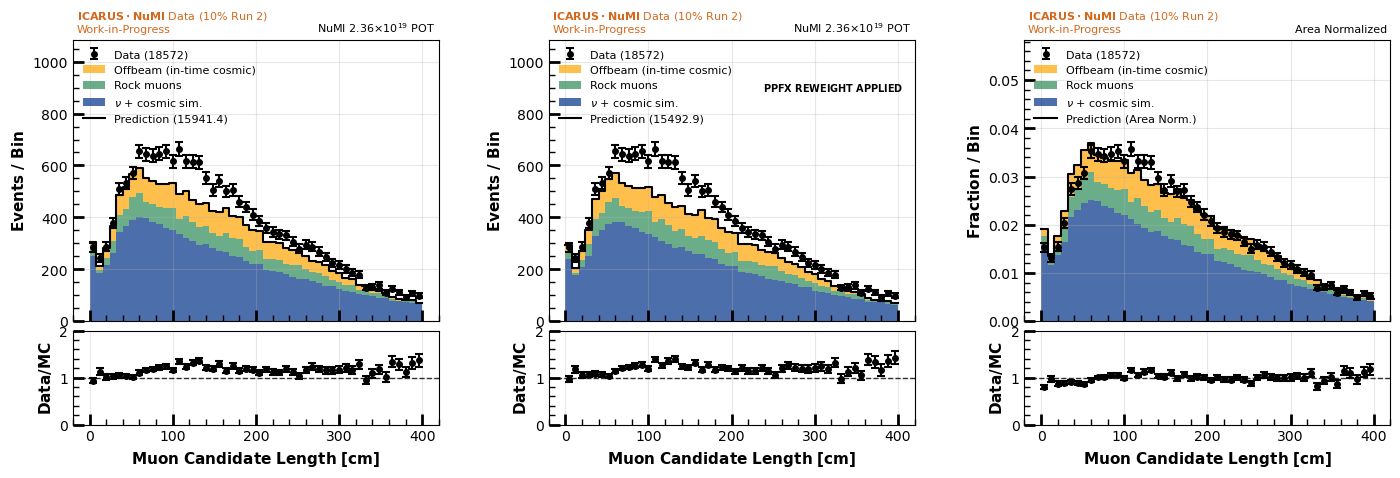

Saved: preselection_track_length  (data 18572, pred 15941.4, ratio 1.165)
Done.


In [8]:
# ============================================================================
# Pre-selection data/MC comparisons, in the style of Section 6.2 (Figs. 54-58)
#
# Three panels per variable: POT-normalized (no flux correction), with the
# PPFX central-value reweight applied to the neutrino-induced components, and
# area-normalized (shape only). Same structure as Howard et al., Sec. 3.2.
#
# Uses the current output file and the current 10-category definition
# (selection/toml/1muNp0pi_Nge1_uncontained.toml, categories 0-9).
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/1muNp0pi_Nge1_uncontained.root")

FLUX_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "systematics/2025-04-08_out_450.37_7991.98_79512.66.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20
horn_current = 'fhc'

# ------------------------------------------------------------------ style ---
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_ppfx_label(ax):
    ax.text(0.97, 0.85, r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$',
            transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

# ------------------------------------------------------------------- load ---
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(),    ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()

f = uproot.open(DATA_FILE)

onbeam_lt   = f["events/onbeam/Livetime"].values().sum()
offbeam_lt  = f["events/offbeam/Livetime"].values().sum()
rock_pot    = f["events/rock/POT"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}  (rock POT = {rock_pot:.4e})")

print("Loading preselection trees...")
mc      = f["events/nominal/preselection"].arrays(library="pd")
rock    = f["events/rock/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")

# --------------------------------------------------------- PPFX weighting ---
def compute_ppfx(df):
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))
    for target_pdg, values, edges in ((14, numu_values, numu_edges),
                                      (-14, numubar_values, numubar_edges)):
        m = (pdg == target_pdg) & np.isfinite(nu_e)
        if m.sum() == 0:
            continue
        e = nu_e[m]
        in_hist = (e >= edges[0]) & (e < edges[-1])
        idx = np.clip(np.searchsorted(edges, e, side='right') - 1, 0, len(values) - 1)
        w[np.where(m)[0]] = np.where(in_hist, values[idx], 1.0)
    return w

mc["ppfx_weight"] = compute_ppfx(mc)
# Rock muons are not part of the beam neutrino flux, so no PPFX reweighting.
rock["ppfx_weight"] = np.ones(len(rock))
print(f"Mean PPFX weight (nominal): {mc['ppfx_weight'].mean():.4f}")

# --------------------------------------------------------------- plotting ---
def make_preselection_plot(variable, xlabel, bins, range_, output_name,
                           require_flash_match=False):
    """POT-normalized | PPFX-applied | area-normalized, three-panel comparison.

    Same structure as Figs. 54-58 in Sec. 6.2: no error bands, no chi2, no
    category or containment breakdown -- data vs. stacked prediction only.
    """
    fig = plt.figure(figsize=(17, 5))
    gs  = gridspec.GridSpec(2, 3, height_ratios=[3, 1], hspace=0.05, wspace=0.3)
    ax0, ax0r = fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[1, 0])
    ax1, ax1r = fig.add_subplot(gs[0, 1]), fig.add_subplot(gs[1, 1])
    ax2, ax2r = fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 2])
    ax0r.sharex(ax0); ax1r.sharex(ax1); ax2r.sharex(ax2)

    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    if require_flash_match:
        mc_mask      = (mc["reco_flash_time"]      > 0.0) & (mc["reco_flash_time"]      < 9.6)
        rock_mask    = (rock["reco_flash_time"]    > 0.0) & (rock["reco_flash_time"]    < 9.6)
        offbeam_mask = (offbeam["reco_flash_time"] > 0.0) & (offbeam["reco_flash_time"] < 9.6)
        onbeam_mask  = (onbeam["reco_flash_time"]  > 0.0) & (onbeam["reco_flash_time"]  < 9.6)
    else:
        mc_mask      = np.ones(len(mc),      dtype=bool)
        rock_mask    = np.ones(len(rock),    dtype=bool)
        offbeam_mask = np.ones(len(offbeam), dtype=bool)
        onbeam_mask  = np.ones(len(onbeam),  dtype=bool)

    w_mc_noppfx   = np.ones(mc_mask.sum())   * mc_scale
    w_mc_ppfx     = mc.loc[mc_mask, "ppfx_weight"].values * mc_scale
    w_rock_noppfx = np.ones(rock_mask.sum()) * rock_scale
    w_rock_ppfx   = rock.loc[rock_mask, "ppfx_weight"].values * rock_scale

    mc_noppfx,   _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_noppfx)
    mc_ppfx,     _ = np.histogram(mc.loc[mc_mask, variable].values,     bins=bins, range=range_, weights=w_mc_ppfx)
    rock_noppfx, _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_noppfx)
    rock_ppfx,   _ = np.histogram(rock.loc[rock_mask, variable].values, bins=bins, range=range_, weights=w_rock_ppfx)
    offbeam_h,   _ = np.histogram(offbeam.loc[offbeam_mask, variable].values, bins=bins, range=range_)
    onbeam_h,    _ = np.histogram(onbeam.loc[onbeam_mask, variable].values,   bins=bins, range=range_)
    onbeam_err     = np.sqrt(onbeam_h)

    offbeam_pot  = offbeam_h * offbeam_scale
    pred_noppfx  = mc_noppfx + rock_noppfx + offbeam_pot
    pred_ppfx    = mc_ppfx   + rock_ppfx   + offbeam_pot

    total_data   = onbeam_h.sum()
    norm_factor  = total_data / pred_noppfx.sum() if pred_noppfx.sum() > 0 else 1.0
    mc_area      = mc_noppfx   * norm_factor / total_data
    rock_area    = rock_noppfx * norm_factor / total_data
    offbeam_area = offbeam_pot * norm_factor / total_data
    pred_area    = pred_noppfx * norm_factor / total_data
    onbeam_area  = onbeam_h    / total_data
    onbeam_area_err = onbeam_err / total_data

    def draw_panel(ax, mc_vals, rock_vals, offbeam_vals, pred_vals,
                   data_vals, data_err, ylabel, pot_str, ppfx=False):
        bottoms = np.zeros(len(bins) - 1)
        ax.bar(bin_centers, mc_vals, width=bin_width, bottom=bottoms,
               color="#003087", alpha=0.7, label=r"$\nu$ + cosmic sim.")
        bottoms = bottoms + mc_vals
        ax.bar(bin_centers, rock_vals, width=bin_width, bottom=bottoms,
               color="seagreen", alpha=0.7, label="Rock muons")
        bottoms = bottoms + rock_vals
        ax.bar(bin_centers, offbeam_vals, width=bin_width, bottom=bottoms,
               color="orange",  alpha=0.7, label="Offbeam (in-time cosmic)")
        ax.step(np.append(bins[:-1], bins[-1]),
                np.append(pred_vals, pred_vals[-1]),
                where='post', color='black', linewidth=1.5,
                label=f"Prediction ({pred_vals.sum():.1f})" if pred_vals.sum() > 1.5 else "Prediction (Area Norm.)")
        ax.errorbar(bin_centers, data_vals, yerr=data_err,
                    fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black",
                    color="black", capsize=3, capthick=1.5, elinewidth=1.5,
                    label=f"Data ({int(total_data)})", zorder=5)
        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ymax = ax.get_ylim()[1]
        ax.set_ylim(0, ymax * 1.5)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[::-1], labels[::-1], fontsize=8, loc='upper left',
                  framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str)
        if ppfx:
            add_ppfx_label(ax)

    def draw_ratio(ax, pred_vals, data_vals, data_err, xlabel):
        with np.errstate(invalid="ignore", divide="ignore"):
            ratio     = np.where(pred_vals > 0, data_vals / pred_vals, np.nan)
            ratio_err = np.where(pred_vals > 0, data_err  / pred_vals, np.nan)
        ax.errorbar(bin_centers, ratio, yerr=ratio_err,
                    fmt='o', markersize=4,
                    markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    pot_str = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"

    draw_panel(ax0, mc_noppfx, rock_noppfx, offbeam_pot, pred_noppfx,
               onbeam_h, onbeam_err, ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=pot_str, ppfx=False)
    draw_ratio(ax0r, pred_noppfx, onbeam_h, onbeam_err, xlabel)

    draw_panel(ax1, mc_ppfx, rock_ppfx, offbeam_pot, pred_ppfx,
               onbeam_h, onbeam_err, ylabel=r"$\mathbf{Events\ /\ Bin}$",
               pot_str=pot_str, ppfx=True)
    draw_ratio(ax1r, pred_ppfx, onbeam_h, onbeam_err, xlabel)

    draw_panel(ax2, mc_area, rock_area, offbeam_area, pred_area,
               onbeam_area, onbeam_area_err, ylabel=r"$\mathbf{Fraction\ /\ Bin}$",
               pot_str="Area Normalized", ppfx=False)
    draw_ratio(ax2r, pred_area, onbeam_area, onbeam_area_err, xlabel)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_name}.pdf"),   bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_name}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)
    print(f"Saved: {output_name}  (data {int(total_data)}, "
          f"pred {pred_noppfx.sum():.1f}, ratio {total_data/pred_noppfx.sum():.3f})")

# ============================================================================
# Generate plots -- same variables and binning as Figs. 54-58
# ============================================================================
make_preselection_plot("reco_flash_time",     "Flash Time [us]",              np.linspace(-5, 15, 51),      (-5, 15),      output_name="preselection_flash_time")
make_preselection_plot("reco_flash_total_pe", "Flash Total PE",               np.linspace(0, 5000, 51),     (0, 5000),     output_name="preselection_flash_total_pe")
make_preselection_plot("reco_vertex_x",       "Reconstructed Vertex X [cm]",  np.linspace(-400, 400, 51),   (-400, 400),   output_name="preselection_vertex_x", require_flash_match=True)
make_preselection_plot("reco_vertex_y",       "Reconstructed Vertex Y [cm]",  np.linspace(-200, 200, 51),   (-200, 200),   output_name="preselection_vertex_y", require_flash_match=True)
make_preselection_plot("reco_vertex_z",       "Reconstructed Vertex Z [cm]",  np.linspace(-1000, 1000, 51), (-1000, 1000), output_name="preselection_vertex_z", require_flash_match=True)
make_preselection_plot("reco_leading_muon_length", "Muon Candidate Length [cm]", np.linspace(0, 400, 51),   (0, 400),      output_name="preselection_track_length", require_flash_match=True)

print("Done.")


In [1]:
# ============================================================================
# Cosmic-rejection power of the in-time flash requirement at pre-selection.
#
# Same kind of study Roy does for the barycenter flash-matching cut and
# Howard does for the clear-cosmic tag: quantify cosmic contamination and
# purity before and after the cut, not just plot a variable.
#
# The only preselection-stage cut available here that targets cosmics is the
# in-time flash requirement (0 < reco_flash_time < 9.6 us), so that is the
# "before / after" boundary. Fiducial + trigger emulation + data quality are
# already baked into the preselection tree and can't be peeled apart without
# a looser tree, so they are not split out here.
#
# Definitions:
#   cosmic       = MC true_category 9 (cosmic, per selection/toml) + offbeam
#                  data (data-driven in-time cosmic estimate)
#   neutrino-Ar  = MC true_category 0-8 (all neutrino interactions in argon,
#                  signal and background alike)
#   rock         = dedicated rock-muon sample (neutrino interactions in the
#                  material surrounding the cryostat); reported separately
#                  since it is neither cosmic nor neutrino-in-argon
#   purity       = neutrino-Ar / total predicted
#   cosmic frac. = cosmic / total predicted
# ============================================================================

import numpy as np
import uproot

DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/1muNp0pi_Nge1_uncontained.root")

ONBEAM_POT   = 2.36124e19
NOMINAL_POT  = 7.178e20

COSMIC_CATEGORY = 9   # per selection/toml/1muNp0pi_Nge1_uncontained.toml

f = uproot.open(DATA_FILE)

onbeam_lt  = f["events/onbeam/Livetime"].values().sum()
offbeam_lt = f["events/offbeam/Livetime"].values().sum()
rock_pot   = f["events/rock/POT"].values().sum()

mc_scale      = ONBEAM_POT / NOMINAL_POT
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print("Loading preselection trees...")
mc      = f["events/nominal/preselection"].arrays(library="pd")
rock    = f["events/rock/preselection"].arrays(library="pd")
onbeam  = f["events/onbeam/preselection"].arrays(library="pd")
offbeam = f["events/offbeam/preselection"].arrays(library="pd")


def flash_matched(df):
    return (df["reco_flash_time"] > 0.0) & (df["reco_flash_time"] < 9.6)


def breakdown(mc_mask, rock_mask, off_mask, label):
    cat = mc["true_category"].values
    is_cosmic = cat == COSMIC_CATEGORY
    is_nu_ar  = np.isfinite(cat) & (cat != COSMIC_CATEGORY)

    n_nu_ar  = (mc_mask & is_nu_ar).sum()  * mc_scale
    n_cosmic = (mc_mask & is_cosmic).sum() * mc_scale
    n_rock   = rock_mask.sum() * rock_scale
    n_off    = off_mask.sum()  * offbeam_scale

    cosmic_total = n_cosmic + n_off
    total        = n_nu_ar + n_rock + cosmic_total

    purity       = n_nu_ar / total if total > 0 else float("nan")
    cosmic_frac  = cosmic_total / total if total > 0 else float("nan")
    rock_frac    = n_rock / total if total > 0 else float("nan")

    print(f"\n--- {label} ---")
    print(f"  neutrino-in-argon (cat 0-8) : {n_nu_ar:10.1f}")
    print(f"  cosmic (MC cat 9 + offbeam) : {cosmic_total:10.1f}  "
          f"(MC {n_cosmic:.1f} + offbeam {n_off:.1f})")
    print(f"  rock muons                  : {n_rock:10.1f}")
    print(f"  total predicted             : {total:10.1f}")
    print(f"  purity (neutrino-in-argon)  : {purity:.1%}")
    print(f"  cosmic contamination        : {cosmic_frac:.1%}")
    print(f"  rock fraction                : {rock_frac:.1%}")
    return dict(total=total, purity=purity, cosmic_frac=cosmic_frac, rock_frac=rock_frac)


all_true = lambda df: np.ones(len(df), dtype=bool)

before = breakdown(all_true(mc), all_true(rock), all_true(offbeam),
                   "Pre-selection (fiducial + trigger + data quality only)")

after = breakdown(flash_matched(mc), flash_matched(rock), flash_matched(offbeam),
                  "+ in-time flash requirement (0 < flash_time < 9.6 us)")

print("\n=========== effect of the in-time flash requirement ===========")
print(f"  purity              : {before['purity']:.1%} -> {after['purity']:.1%}")
print(f"  cosmic contamination: {before['cosmic_frac']:.1%} -> {after['cosmic_frac']:.1%}")
print(f"  rock fraction        : {before['rock_frac']:.1%} -> {after['rock_frac']:.1%}")
print(f"  total predicted sample retained: "
      f"{after['total']/before['total']:.1%} of pre-cut prediction")

n_on_before = len(onbeam)
n_on_after  = int(flash_matched(onbeam).sum())
print(f"  data events retained: {n_on_after} / {n_on_before} "
      f"({n_on_after/n_on_before:.1%})")

print("\nDone.")


Loading preselection trees...

--- Pre-selection (fiducial + trigger + data quality only) ---
  neutrino-in-argon (cat 0-8) :    24296.8
  cosmic (MC cat 9 + offbeam) :  1167647.2  (MC 613329.7 + offbeam 554317.5)
  rock muons                  :  3853138.2
  total predicted             :  5045082.3
  purity (neutrino-in-argon)  : 0.5%
  cosmic contamination        : 23.1%
  rock fraction                : 76.4%

--- + in-time flash requirement (0 < flash_time < 9.6 us) ---
  neutrino-in-argon (cat 0-8) :    15750.2
  cosmic (MC cat 9 + offbeam) :     6039.5  (MC 2666.4 + offbeam 3373.1)
  rock muons                  :     3695.4
  total predicted             :    25485.0
  purity (neutrino-in-argon)  : 61.8%
  cosmic contamination        : 23.7%
  rock fraction                : 14.5%

=========== effect of the in-time flash requirement ===========
  purity              : 0.5% -> 61.8%
  cosmic contamination: 23.1% -> 23.7%
  rock fraction        : 76.4% -> 14.5%
  total predicted sample

CELL VERSION: trigger_time_v10_rock_noncosmic_is_default_2026-08-18
Reading exposures (trigger_time tree)...
    onbeam: POT read from events/onbeam/POT histogram = 2.216270e+19
    onbeam: Livetime read from events/onbeam/Livetime histogram = 4.839580e+05
    offbeam: POT read from events/offbeam/POT histogram = 0.000000e+00
    offbeam: Livetime read from events/offbeam/Livetime histogram = 1.013688e+06
    rock: POT read from events/rock/POT histogram = 4.372197e+18
    rock: Livetime read from events/rock/Livetime histogram = 5.172000e+04
    nominal: POT read from events/nominal/POT histogram = 3.118401e+20
    nominal: Livetime read from events/nominal/Livetime histogram = 6.012000e+05

Onbeam POT (raw, from file)                : 2.216270e+19
Onbeam POT (validated, histogram-integration): 2.361240e+19  (Moreno, NuMI POT Counting Closure Test, Apr 1 2025)
Offbeam livetime correction factor          : 1.065411  (= ONBEAM_POT / onbeam_pot_raw -- ASSUMED to also apply to offbeam liv

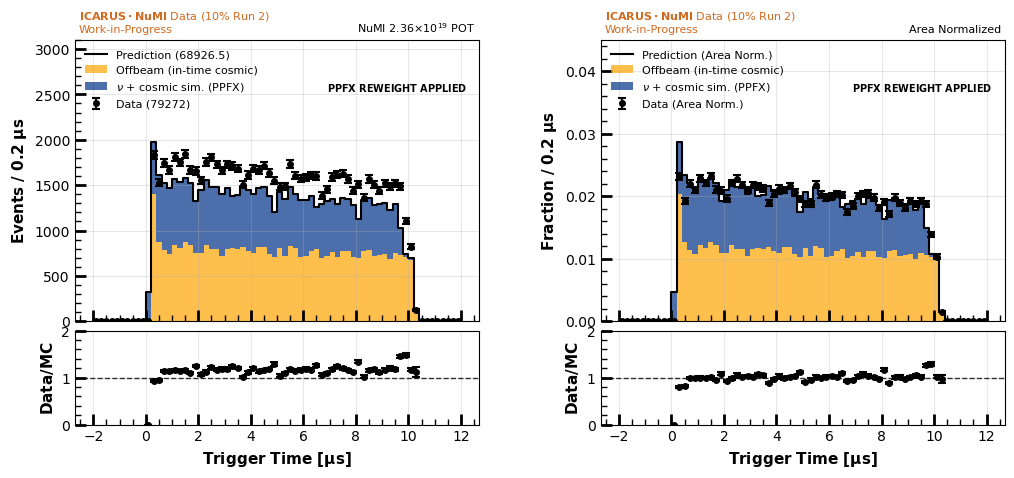


--- trigger_time [Rock excluded (Howard Fig. 7 style)] (POT-normalized | area-normalized, PPFX applied) ---
  rows loaded: mc 601200  rock 0 (0 if excluded)  onbeam 79272  offbeam 87238
  data               : 79272
  prediction         : 68926.5 +/- 141.0 (stat)
    nu+cosmic sim    : 29834.2
    rock muons       : excluded from this case
    offbeam (cosmic) : 39092.3
  data/MC            : 1.1501 +/- 0.0047
  folded into edge bins: underflow 0, overflow 0

  excluded as 'no usable event_trigger_within_gate' (<= -1e+10, i.e. the -DBL_MAX sentinel):
     nominal:  224459 /  601200 rows (37.3%)  -- scaled weight excluded: 17772.7
      onbeam:       0 /   79272 rows (0.0%)  -- scaled weight excluded: 0.0
     offbeam:       0 /   87238 rows (0.0%)  -- scaled weight excluded: 0.0


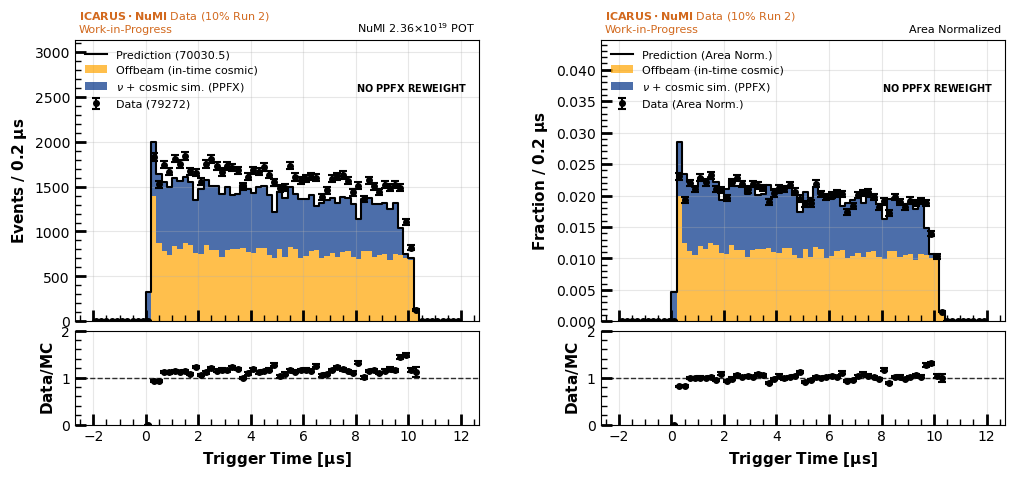


--- trigger_time [Rock excluded (Howard Fig. 7 style)] (POT-normalized | area-normalized, no PPFX) ---
  rows loaded: mc 601200  rock 0 (0 if excluded)  onbeam 79272  offbeam 87238
  data               : 79272
  prediction         : 70030.5 +/- 141.6 (stat)
    nu+cosmic sim    : 30938.1
    rock muons       : excluded from this case
    offbeam (cosmic) : 39092.3
  data/MC            : 1.1320 +/- 0.0046
  folded into edge bins: underflow 0, overflow 0

  excluded as 'no usable event_trigger_within_gate' (<= -1e+10, i.e. the -DBL_MAX sentinel):
     nominal:  224459 /  601200 rows (37.3%)  -- scaled weight excluded: 18432.7
      onbeam:       0 /   79272 rows (0.0%)  -- scaled weight excluded: 0.0
     offbeam:       0 /   87238 rows (0.0%)  -- scaled weight excluded: 0.0


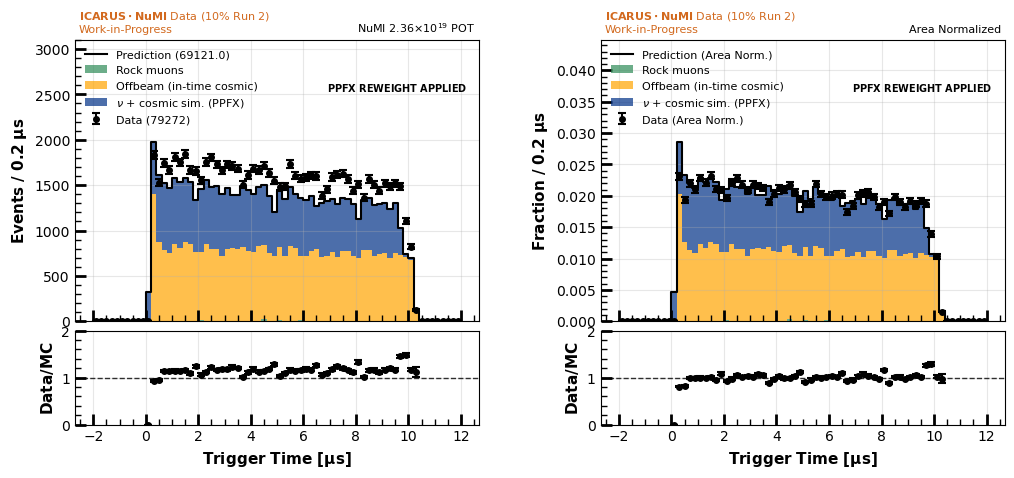


--- trigger_time [Rock included (genuine GENIE-linked rock muons only, category != 9)] (POT-normalized | area-normalized, PPFX applied) ---
  rows loaded: mc 601200  rock 80 (0 if excluded)  onbeam 79272  offbeam 87238
  data               : 79272
  prediction         : 69121.0 +/- 144.7 (stat)
    nu+cosmic sim    : 29834.2
    rock muons       : 194.4  (category != 9 only (genuine GENIE-linked rock muons, cosmic-like contamination removed))
    offbeam (cosmic) : 39092.3
  data/MC            : 1.1469 +/- 0.0047
  folded into edge bins: underflow 0, overflow 0

  excluded as 'no usable event_trigger_within_gate' (<= -1e+10, i.e. the -DBL_MAX sentinel):
     nominal:  224459 /  601200 rows (37.3%)  -- scaled weight excluded: 17772.7
        rock:      44 /      80 rows (55.0%)  -- scaled weight excluded: 237.6
      onbeam:       0 /   79272 rows (0.0%)  -- scaled weight excluded: 0.0
     offbeam:       0 /   87238 rows (0.0%)  -- scaled weight excluded: 0.0


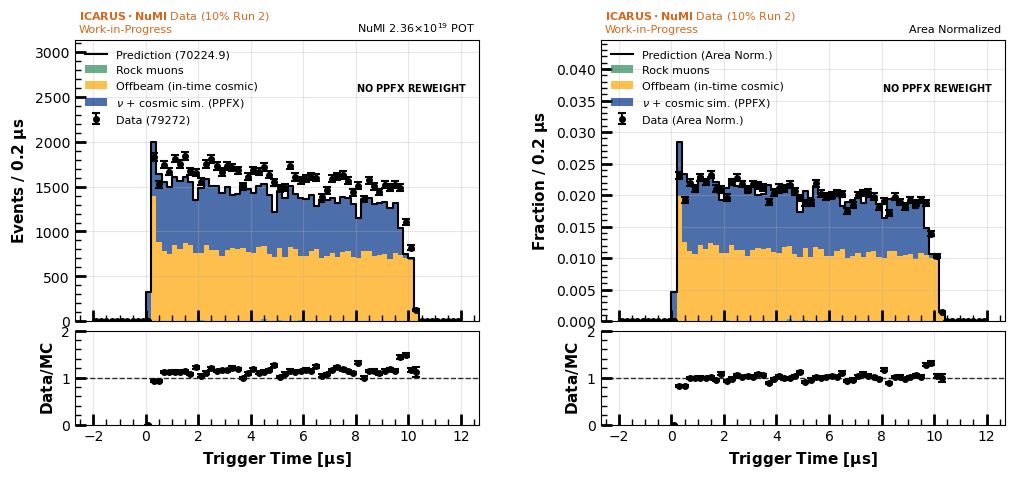


--- trigger_time [Rock included (genuine GENIE-linked rock muons only, category != 9)] (POT-normalized | area-normalized, no PPFX) ---
  rows loaded: mc 601200  rock 80 (0 if excluded)  onbeam 79272  offbeam 87238
  data               : 79272
  prediction         : 70224.9 +/- 145.3 (stat)
    nu+cosmic sim    : 30938.1
    rock muons       : 194.4  (category != 9 only (genuine GENIE-linked rock muons, cosmic-like contamination removed))
    offbeam (cosmic) : 39092.3
  data/MC            : 1.1288 +/- 0.0046
  folded into edge bins: underflow 0, overflow 0

  excluded as 'no usable event_trigger_within_gate' (<= -1e+10, i.e. the -DBL_MAX sentinel):
     nominal:  224459 /  601200 rows (37.3%)  -- scaled weight excluded: 18432.7
        rock:      44 /      80 rows (55.0%)  -- scaled weight excluded: 237.6
      onbeam:       0 /   79272 rows (0.0%)  -- scaled weight excluded: 0.0
     offbeam:       0 /   87238 rows (0.0%)  -- scaled weight excluded: 0.0

=========== rock on/off, PPFX

In [42]:
# ============================================================================
# Trigger-time preselection plot (Howard Fig. 7/8 replica), from the new
# `trigger_time` tree in selection/toml/preselection.toml.
#
# `trigger_time` is a mode = "event" tree: one row per triggered event, not
# one row per reconstructed interaction like `preselection`. That is a real
# structural consequence of how selection/src/framework.cc dispatches branch
# construction (see the comment block in preselection.toml) -- not a
# simplification chosen here. A mode = "event" tree can only carry branches
# of type = "event" (framework.cc's Mode::Event block only recognizes that
# one type), so `true_pdg` / `true_neutrino_energy` (both type = "mctruth")
# are NOT available directly on this tree -- there is no way to compute the
# PPFX weight from `trigger_time` alone.
#
# PPFX weight, via a join to `preselection`:
#   Both `trigger_time` and `preselection` were confirmed (previous cells) to
#   carry Run/Subrun/Evt columns, so the per-event PPFX weight is obtained by
#   building a (Run, Subrun, Evt) -> (true_pdg, true_neutrino_energy) lookup
#   from `events/nominal/preselection` and merging it onto `trigger_time`.
#   This join is NOT complete: `preselection`'s cuts include `fiducial_cut`
#   (a reco-level, row-filtering cut -- only interactions reconstructed
#   inside the fiducial volume get a row there), while `trigger_time`'s only
#   cuts are the two event-level ones. So a `trigger_time` row for an event
#   with no fiducial-volume interaction (none reconstructed, or reconstructed
#   outside the FV) will not find a match. The match fraction is measured and
#   printed below rather than assumed; unmatched rows get PPFX weight 1.0
#   (the same fallback compute_ppfx already uses for non-numu/numubar PDGs),
#   which is reported explicitly so it isn't a silent bias.
#
# Rock is NOT PPFX-reweighted (standing instruction: rock muons are not beam
# neutrinos). Also per the previous cell's finding, 99.9% of
# events/rock/preselection rows are true_category == 9 (nu_id < 0, no
# matched neutrino truth) -- both the "rock excluded" (Howard Fig. 7 style)
# and "rock included" (Howard Fig. 8 style, same double-counting caveat
# Howard notes for his own plot) cases are produced below.
#
# Area-normalized panel dropped per instruction -- POT-normalized only.
#
# Self-contained: re-imports and re-defines everything it needs.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

print("CELL VERSION: trigger_time_v10_rock_noncosmic_is_default_2026-08-18")

# ------------------------------------------------------------------ config --
DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/preselection.root")

FLUX_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "systematics/2025-04-08_out_450.37_7991.98_79512.66.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ONBEAM_POT  = 2.36124e19
MC_SAMPLE   = "nominal"
TREE        = "trigger_time"
horn_current = 'fhc'
# NOMINAL_POT is deliberately NOT hardcoded here (unlike other cells in this
# notebook): this file was built from a partial job set (~199 hadd source
# files, not the full production used for 1muNp0pi_Nge1_uncontained.root),
# so its generated POT is smaller than the 7.178e20 used elsewhere. It is
# read from the file itself below, the same way rock_pot already is.

# ------------------------------------------------------------------ style ---
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

# ------------------------------------------------------------------- load ---
f = uproot.open(DATA_FILE)
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(),    ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()


def read_exposure(sample, tree=TREE):
    """Same fallback logic used for the `preselection` tree elsewhere in this
    notebook: POT/Livetime histograms if present, else the <tree>_exposure
    tree. Prints which source it used and the raw value(s), every time --
    not just on a naming mismatch -- so this is auditable rather than a
    black box for a sample like rock where the number matters a lot."""
    pot = lt = None
    if f"events/{sample}/POT" in f:
        pot = f[f"events/{sample}/POT"].values().sum()
        print(f"    {sample}: POT read from events/{sample}/POT histogram = {pot:.6e}")
    if f"events/{sample}/Livetime" in f:
        lt = f[f"events/{sample}/Livetime"].values().sum()
        print(f"    {sample}: Livetime read from events/{sample}/Livetime histogram = {lt:.6e}")
    if pot is not None or lt is not None:
        return pot, lt

    key = f"events/{sample}/{tree}_exposure"
    if key not in f:
        raise KeyError(f"no exposure information found for sample '{sample}' "
                       f"(looked for events/{sample}/POT, /Livetime and {key})")
    t = f[key]
    print(f"    {sample}/{tree}_exposure branches: {t.keys()}")
    arrays = t.arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
            print(f"    {sample}: POT summed from {tree}_exposure branch '{name}' = {pot:.6e}")
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
            print(f"    {sample}: Livetime summed from {tree}_exposure branch '{name}' = {lt:.6e}")
    return pot, lt


print("Reading exposures (trigger_time tree)...")
onbeam_pot_raw, onbeam_lt  = read_exposure("onbeam")
_,              offbeam_lt_raw = read_exposure("offbeam")
rock_pot,        _      = read_exposure("rock")
nominal_pot_raw, _      = read_exposure(MC_SAMPLE)

for label, val in (("onbeam POT (raw)", onbeam_pot_raw), ("onbeam livetime", onbeam_lt),
                   ("offbeam livetime (raw)", offbeam_lt_raw),
                   ("rock POT", rock_pot), ("nominal MC POT (raw)", nominal_pot_raw)):
    if val is None or not np.isfinite(val) or val <= 0:
        raise ValueError(f"{label} came back as {val}. Check the exposure branch "
                         f"names printed above.")

# Offbeam livetime correction (heuristic, NOT independently validated):
# the NuMI POT-counting closure test (Moreno, ICARUS Cross-Section Analysis
# Meeting, Apr 1 2025) showed that for this same prescaled Run2 "good runs"
# sample, the raw events/onbeam/POT histogram sum (2.21627e19, read above)
# undercounts the validated POT (ONBEAM_POT = 2.36124e19, cross-checked via
# an independent histogram-integration method built from real per-spill
# accelerator quantities). The stated cause: CAF metadata (sr->hdr.pot) is
# only stored on the first event of each 50-event CAF file, so any per-event
# accounting undercounts for a prescaled/reduced sample.
#
# Offbeam is real data run through presumably the same CAF/medulla pipeline,
# so its raw Livetime histogram could plausibly suffer the same fractional
# undercount -- but there is no independent cross-check for offbeam livetime
# analogous to the onbeam POT closure test, so this is an ASSUMPTION: that
# offbeam's raw livetime is undercounted by the same fractional rate as
# onbeam's raw POT was. Applied as a proportional correction, not derived
# independently for offbeam.
OFFBEAM_LIVETIME_CORRECTION_FACTOR = ONBEAM_POT / onbeam_pot_raw
offbeam_lt = offbeam_lt_raw * OFFBEAM_LIVETIME_CORRECTION_FACTOR
print(f"\nOnbeam POT (raw, from file)                : {onbeam_pot_raw:.6e}")
print(f"Onbeam POT (validated, histogram-integration): {ONBEAM_POT:.6e}  "
      f"(Moreno, NuMI POT Counting Closure Test, Apr 1 2025)")
print(f"Offbeam livetime correction factor          : {OFFBEAM_LIVETIME_CORRECTION_FACTOR:.6f}  "
      f"(= ONBEAM_POT / onbeam_pot_raw -- ASSUMED to also apply to offbeam livetime, "
      f"not independently validated for offbeam)")
print(f"Offbeam livetime (raw, from file)           : {offbeam_lt_raw:.6e}")
print(f"Offbeam livetime (corrected, heuristic)     : {offbeam_lt:.6e}")

# Correction for broken/recovered job files: the build log for this partial
# job set showed several hadd source files needed TFile::Recover, so the raw
# POT histogram sum undercounts the true generated POT. For the COMPLETE
# production the raw (uncorrected) POT was 7.78520e+20 and the corrected
# true POT was 7.178390e+20 -- that same raw-to-corrected ratio is applied
# here, on the (reasonable, but not independently re-derived) assumption
# that the same per-file recovery loss rate holds for this partial job set.
POT_CORRECTION_FACTOR = 7.178390e20 / 7.78520e20
nominal_pot = nominal_pot_raw * POT_CORRECTION_FACTOR

mc_scale      = ONBEAM_POT / nominal_pot
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"Nominal MC POT (raw, from file) : {nominal_pot_raw:.4e}")
print(f"POT correction factor           : {POT_CORRECTION_FACTOR:.6f}  "
      f"(= 7.178390e+20 / 7.78520e+20, derived for the NOMINAL partial job set "
      f"-- NOT yet applied to rock_pot below, since it is not established "
      f"that rock came from the same broken-file batch)")
print(f"Nominal MC POT (corrected)      : {nominal_pot:.4e}")
print(f"Rock POT (raw, from file)       : {rock_pot:.4e}")
print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}")
print(f"\nRock scale / MC scale = {rock_scale/mc_scale:.2f}x -- i.e. each valid rock row "
      f"is weighted {rock_scale/mc_scale:.1f}x more than each valid nominal-MC row. "
      f"This ratio is exactly (nominal_pot / rock_pot) = "
      f"({nominal_pot:.4e} / {rock_pot:.4e}) = {nominal_pot/rock_pot:.2f}. "
      f"If rock_pot is undercounted for the same reason nominal_pot_raw was "
      f"(broken/recovered hadd source files in this partial job set), this "
      f"ratio -- and therefore the rock component of the plot -- would be "
      f"inflated by exactly that undercount factor. This has NOT been "
      f"verified yet; it is the leading remaining hypothesis after ruling "
      f"out the missing-fiducial-cut explanation above.")

print(f"\nLoading '{TREE}' trees...")
mc      = f[f"events/{MC_SAMPLE}/{TREE}"].arrays(library="pd")
rock    = f[f"events/rock/{TREE}"].arrays(library="pd")
onbeam  = f[f"events/onbeam/{TREE}"].arrays(library="pd")
offbeam = f[f"events/offbeam/{TREE}"].arrays(library="pd")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    print(f"  {name:>8}: {len(df)} rows, columns = {list(df.columns)}")

# ----------------------------------------------------- resolve branch name --
candidates = [c for c in mc.columns if "trigger_within_gate" in c]
if len(candidates) != 1:
    raise KeyError(f"expected exactly one column matching 'trigger_within_gate' "
                   f"in the {TREE} tree, found {candidates}. "
                   f"Available columns: {list(mc.columns)}")
TRIGGER_BRANCH = candidates[0]
print(f"\nUsing branch '{TRIGGER_BRANCH}' for trigger time.")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    missing = [k for k in ("Run", "Subrun", "Evt") if k not in df.columns]
    if missing:
        raise KeyError(f"{name}/{TREE} is missing join key column(s) {missing}")

# --------------------------------- rock: restrict to FV rock interactions --
# `trigger_time` is a mode="event" tree with NO fiducial_cut -- event-mode
# trees cannot evaluate reco-level cuts (see the header comment). For
# nominal/onbeam/offbeam that means "any triggered event", which is exactly
# how Howard describes his own trigger-time validation plot. For rock,
# though, "any triggered event" is a much bigger population than "rock muons
# that actually produced a fiducial-volume interaction": most rock muons
# never enter the FV, they just cross the detector and trigger. That
# mismatch is the leading candidate for why the rock (green) component below
# was so much larger than in Howard's Fig. 8 -- not yet confirmed against the
# data, which is what the printout right after this cell fixes does.
#
# Fixed the same way the PPFX join already works around the same structural
# limitation: restrict rock/trigger_time rows to only those whose
# (Run, Subrun, Evt) key also appears in rock/preselection, i.e. rows that
# rock/preselection's own fiducial_cut has already confirmed are a genuine
# FV interaction.
rock_presel_keys = f["events/rock/preselection"].arrays(
    ["Run", "Subrun", "Evt", "true_category"], library="pd")
rock_fv_keyset = set(map(tuple, rock_presel_keys[["Run", "Subrun", "Evt"]].values))
n_rock_before = len(rock)
rock_row_keys = list(map(tuple, rock[["Run", "Subrun", "Evt"]].values))
rock_is_fv = np.array([k in rock_fv_keyset for k in rock_row_keys])
rock = rock[rock_is_fv].reset_index(drop=True)
print(f"\nRestricting rock/{TREE} to FV-contained rock interactions "
      f"(matched against events/rock/preselection's own fiducial_cut):")
print(f"  rock/{TREE} rows before restriction : {n_rock_before}")
print(f"  rock/{TREE} rows after restriction  : {len(rock)}  "
      f"({len(rock)/n_rock_before:.1%} kept, {1 - len(rock)/n_rock_before:.1%} were "
      f"rock triggers with no matching FV interaction in rock/preselection)")

# --------------------------- rock: isolate genuine (non-cosmic) rock muons --
# true_category == 9 is the toml's own "Cosmic" label (defined via the
# !neutrino cut, i.e. no matched GENIE neutrino truth at all) -- confirmed
# two cells ago to be 99.9% of events/rock/preselection rows. Combined with
# the corrected-POT script's finding that mc.nnu > 0 for 100% of rock
# subruns (a GENIE neutrino WAS generated in every subrun), this means the
# rock production bundles two physically different things together: genuine
# GENIE neutrino-in-rock interactions (category != 9) and standalone
# simulated cosmic muons riding along in the same files (category == 9,
# exactly the "simulated cosmic muons ... which may have some double
# counting effect with the in-time offbeam sample" Howard describes for his
# own rock-included plot). Since the latter represents the same physical
# population offbeam already measures independently, isolating category != 9
# rock rows should approximate "just the genuine rock-muon background,
# cosmic duplication removed."
rock_cat_lookup = rock_presel_keys.drop_duplicates(subset=["Run", "Subrun", "Evt"], keep="first")
rock_j = rock.merge(rock_cat_lookup[["Run", "Subrun", "Evt", "true_category"]],
                    on=["Run", "Subrun", "Evt"], how="left")
n_cat_matched = int(np.isfinite(rock_j["true_category"].values).sum())
n_noncosmic = int((rock_j["true_category"].values != 9).sum())  # NaN != 9 is True, so also require matched
n_noncosmic = int(((rock_j["true_category"].values != 9) & np.isfinite(rock_j["true_category"].values)).sum())
print(f"\nrock/{TREE} true_category composition (via the same Run/Subrun/Evt join):")
print(f"  matched to a rock/preselection row with a category : {n_cat_matched} / {len(rock_j)} "
      f"({n_cat_matched/len(rock_j):.1%})")
print(f"  category != 9 (genuine GENIE-linked rock muon)      : {n_noncosmic} / {len(rock_j)} "
      f"({n_noncosmic/len(rock_j):.1%})")
print(f"  category == 9 (standalone simulated cosmic, no GENIE"
      f" match) : {n_cat_matched - n_noncosmic} / {len(rock_j)} "
      f"({(n_cat_matched - n_noncosmic)/len(rock_j):.1%})")
rock_noncosmic_mask = ((rock_j["true_category"].values != 9)
                       & np.isfinite(rock_j["true_category"].values))
rock_noncosmic = rock[rock_noncosmic_mask].reset_index(drop=True)
v_rock_noncosmic = rock_noncosmic[TRIGGER_BRANCH].values

# ------------------------------------------------- PPFX weight via join ---
def compute_ppfx(df):
    """PPFX CV weight per row, numu/numubar only; everything else stays 1.0.
    Identical logic to the compute_ppfx used for the `preselection` tree
    elsewhere in this notebook."""
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))
    for target_pdg, values, edges in ((14, numu_values, numu_edges),
                                      (-14, numubar_values, numubar_edges)):
        m = (pdg == target_pdg) & np.isfinite(nu_e)
        if m.sum() == 0:
            continue
        e = nu_e[m]
        in_hist = (e >= edges[0]) & (e < edges[-1])
        idx = np.clip(np.searchsorted(edges, e, side='right') - 1, 0, len(values) - 1)
        w[np.where(m)[0]] = np.where(in_hist, values[idx], 1.0)
    return w


print(f"\nBuilding (Run, Subrun, Evt) -> (true_pdg, true_neutrino_energy) lookup "
      f"from events/{MC_SAMPLE}/preselection for the PPFX join...")
presel_truth = f[f"events/{MC_SAMPLE}/preselection"].arrays(
    ["true_pdg", "true_neutrino_energy", "Run", "Subrun", "Evt"], library="pd")
presel_truth = presel_truth[np.isfinite(presel_truth["true_pdg"].values)]
print(f"  {len(presel_truth)} truth-matched rows before dedup")

grp = presel_truth.groupby(["Run", "Subrun", "Evt"])
n_incons = int((grp["true_pdg"].nunique() > 1).sum())
if n_incons > 0:
    print(f"  WARNING: {n_incons} (Run,Subrun,Evt) keys have more than one distinct "
          f"true_pdg value -- taking the first row for those, not silently averaging.")
lookup = presel_truth.drop_duplicates(subset=["Run", "Subrun", "Evt"], keep="first")
print(f"  {len(lookup)} unique (Run,Subrun,Evt) keys in the lookup")

mc_j = mc.merge(lookup[["Run", "Subrun", "Evt", "true_pdg", "true_neutrino_energy"]],
                on=["Run", "Subrun", "Evt"], how="left")
n_matched = int(np.isfinite(mc_j["true_pdg"].values).sum())
print(f"  matched {n_matched} / {len(mc_j)} nominal trigger_time rows "
      f"({n_matched/len(mc_j):.1%}) to a fiducial-volume interaction in preselection.")
print(f"  the remaining {len(mc_j)-n_matched} rows ({(len(mc_j)-n_matched)/len(mc_j):.1%}) "
      f"get PPFX weight 1.0 (no fiducial-volume interaction to look up a true "
      f"neutrino energy/flavor from) -- not reweighted, not excluded.")

mc_j["ppfx_weight"] = compute_ppfx(mc_j)
print(f"  mean PPFX weight (nominal, whole trigger_time tree): {mc_j['ppfx_weight'].mean():.4f}")
mc = mc_j
# Rock is not reweighted (standing instruction), so rock keeps weight 1.0 implicitly.

# --------------------------------------------------------------- helpers ---
# The min value of event_trigger_within_gate is exactly
# -1.7976931348623157e+308 = -DBL_MAX for a large fraction of MC rows (37.3%
# of nominal, 86.9% of rock) and ZERO data rows -- a placeholder for "no
# value" (trigger_emulation_cut only requires global_trigger_det_time to be
# non-NaN, a DIFFERENT field), not a real trigger time. Excluded from the
# histogram and reported separately, the same way 'reco_flash_total_pe < 0'
# is treated elsewhere in this notebook.
TRIGGER_SENTINEL_THRESHOLD = -1.0e10   # real values sit in roughly [-2, 12]

def _hist_with_overflow(values, weights, bins, valid=None):
    values  = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)

    good = np.isfinite(values)
    if valid is not None:
        good &= np.asarray(valid, dtype=bool)

    v, w = values[good], weights[good]
    n_bad = int((~good).sum())
    sumw_bad, sumw2_bad = weights[~good].sum(), (weights[~good] ** 2).sum()

    n_under = int((v < bins[0]).sum())
    n_over  = int((v > bins[-1]).sum())
    v = np.clip(v, bins[0], np.nextafter(bins[-1], bins[0]))
    sumw,  _ = np.histogram(v, bins=bins, weights=w)
    sumw2, _ = np.histogram(v, bins=bins, weights=w * w)
    return dict(sumw=sumw, sumw2=sumw2, n_under=n_under, n_over=n_over,
                n_good=int(good.sum()), n_bad=n_bad,
                sumw_bad=sumw_bad, sumw2_bad=sumw2_bad)


def _ratio_err(d, p, pe):
    if p <= 0:
        return np.nan
    return (d / p) * np.sqrt(1.0 / max(d, 1.0) + (pe / p) ** 2)


# --------------------------------------------------------------- plotting ---
# Bin width 0.2 us, range -2 to 12 us, matching Howard Fig. 7's own axis
# ("Trigger time (us)", "Events / 0.2 us", range -2 to 12) -- read directly
# off the technote figure, not chosen independently.
BINS = np.linspace(-2.0, 12.0, 71)
bin_centers = 0.5 * (BINS[:-1] + BINS[1:])
bin_width   = BINS[1:] - BINS[:-1]

v_mc, v_rock, v_off, v_on = (mc[TRIGGER_BRANCH].values, rock[TRIGGER_BRANCH].values,
                             offbeam[TRIGGER_BRANCH].values, onbeam[TRIGGER_BRANCH].values)
w_mc_ppfx    = mc["ppfx_weight"].values
w_mc_no_ppfx = np.ones(len(mc))

def _valid(v):
    return np.asarray(v, dtype=float) > TRIGGER_SENTINEL_THRESHOLD

pot_str = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"


def run_trigger_time_case(include_rock, case_label, output_suffix, show_label, use_ppfx=True,
                          rock_values=None):
    """Build and plot one version of the trigger-time comparison: POT-normalized
    and area-normalized side by side. Nominal MC is PPFX weighted via the join
    above; rock (if included) is not.

    include_rock=False -> Howard Fig. 7: nu+cosmic sim + offbeam only.
    include_rock=True  -> Howard Fig. 8: adds rock, with the caveat
                           (confirmed in the previous cell: 99.9% of
                           events/rock/preselection rows are
                           true_category == 9 / nu_id < 0) that this
                           component may double count with offbeam.
    show_label -> whether to draw the case_label as a suptitle / corner note
                  (off for the rock-excluded case, per instruction).
    rock_values -> which rock array to histogram when include_rock=True.
                  Defaults to v_rock (all FV-matched rock rows, category 9
                  and non-9 mixed). Pass v_rock_noncosmic instead to use only
                  rows matched to a genuine (non-cosmic, category != 9)
                  GENIE-linked rock/preselection interaction.
    use_ppfx -> True applies the PPFX flux reweight to the nominal MC (via
                the join above); False instead weights nominal MC by 1.0
                (still POT-scaled by mc_scale), so the two cases isolate the
                effect of the PPFX reweight itself.
    """
    w_mc  = w_mc_ppfx if use_ppfx else w_mc_no_ppfx
    h_mc  = _hist_with_overflow(v_mc,  w_mc * mc_scale, BINS, _valid(v_mc))
    h_off = _hist_with_overflow(v_off, np.ones(len(v_off)), BINS, _valid(v_off))
    h_dat = _hist_with_overflow(v_on,  np.ones(len(v_on)), BINS, _valid(v_on))

    mc_h  = h_mc['sumw']
    off_h = h_off['sumw'] * offbeam_scale
    off_var = h_off['sumw'] * offbeam_scale ** 2
    dat_h = h_dat['sumw']
    dat_err = np.sqrt(dat_h)
    n_data = int(dat_h.sum())

    if include_rock:
        rv = v_rock if rock_values is None else rock_values
        h_rk = _hist_with_overflow(rv, np.full(len(rv), rock_scale), BINS, _valid(rv))
        rk_h = h_rk['sumw']
        rk_sumw2, rk_n_under, rk_n_over, rk_n_bad, rk_sumw_bad = (
            h_rk['sumw2'], h_rk['n_under'], h_rk['n_over'], h_rk['n_bad'], h_rk['sumw_bad'])
    else:
        h_rk = None
        rk_h = np.zeros_like(mc_h)
        rk_sumw2 = np.zeros_like(mc_h)
        rk_n_under = rk_n_over = rk_n_bad = 0
        rk_sumw_bad = 0.0

    pred   = mc_h + rk_h + off_h
    pred_e = np.sqrt(h_mc['sumw2'] + rk_sumw2 + off_var)

    tot_p = pred.sum()
    mc_a, rk_a, off_a = mc_h / tot_p, rk_h / tot_p, off_h / tot_p
    pred_a, pred_a_e  = pred / tot_p, pred_e / tot_p
    dat_a, dat_a_err  = dat_h / n_data, dat_err / n_data

    u_tot = h_mc['n_under'] + rk_n_under + h_off['n_under'] + h_dat['n_under']
    o_tot = h_mc['n_over']  + rk_n_over  + h_off['n_over']  + h_dat['n_over']

    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.3)
    tops = [fig.add_subplot(gs[0, i]) for i in range(2)]
    bots = [fig.add_subplot(gs[1, i], sharex=tops[i]) for i in range(2)]

    def draw_panel(ax, mcv, rkv, offv, predv, dv, derr, ylabel, pot_str_,
                  corner=None, show_counts=True):
        # Stacking order (bottom to top): rock (if included), then offbeam,
        # then nu+cosmic sim on top -- so top-to-bottom reads blue, yellow,
        # green, per instruction.
        base = np.zeros(len(BINS) - 1)
        if include_rock:
            ax.bar(bin_centers, rkv,  width=bin_width, bottom=base, color="seagreen",
                   alpha=0.7, label="Rock muons")
            base = base + rkv
        ax.bar(bin_centers, offv, width=bin_width, bottom=base, color="orange",
               alpha=0.7, label="Offbeam (in-time cosmic)")
        base = base + offv
        ax.bar(bin_centers, mcv,  width=bin_width, bottom=base, color="#003087",
               alpha=0.7, label=r"$\nu$ + cosmic sim. (PPFX)")

        # Total stacked height at bin j = predv[j] (mc+rock+offbeam) regardless
        # of stacking order, so use predv directly rather than `base` (which
        # now depends on which component was drawn last).
        for j, n_extra in ((0, u_tot), (len(BINS) - 2, o_tot)):
            if n_extra > 0:
                ax.bar(bin_centers[j], predv[j], width=bin_width[j],
                       fill=False, edgecolor='black', hatch='///', linewidth=0.0, zorder=4)

        ax.step(np.append(BINS[:-1], BINS[-1]), np.append(predv, predv[-1]),
                where='post', color='black', linewidth=1.5,
                label=(f"Prediction ({predv.sum():.1f})" if show_counts else "Prediction (Area Norm.)"))
        ax.errorbar(bin_centers, dv, yerr=derr, fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black", color="black",
                    capsize=3, capthick=1.5, elinewidth=1.5,
                    label=(f"Data ({n_data})" if show_counts else "Data (Area Norm.)"), zorder=5)

        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
        # Legend order matches draw order (rock first if present, then
        # offbeam, then nu+cosmic sim, then prediction/data).
        h, l = ax.get_legend_handles_labels()
        ax.legend(h, l, fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str_)
        if corner:
            add_corner_label(ax, corner)

    def draw_ratio(ax, predv, dv, derr):
        with np.errstate(invalid="ignore", divide="ignore"):
            r    = np.where(predv > 0, dv / predv, np.nan)
            rerr = np.where(predv > 0, derr / predv, np.nan)
        inside = np.isfinite(r) & (r >= 0.0) & (r <= 2.0)
        ax.errorbar(bin_centers[inside], r[inside], yerr=rerr[inside],
                    fmt='o', markersize=4, markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        hi = np.isfinite(r) & (r > 2.0)
        if hi.any():
            ax.plot(bin_centers[hi], np.full(hi.sum(), 1.92), marker='^', linestyle='none',
                    markersize=5, color='red')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{Trigger\ Time\ [\mu s]}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    corner_text = (r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$' if use_ppfx
                   else r'$\mathbf{NO\ PPFX\ REWEIGHT}$') + (f"\n{case_label}" if show_label else "")

    draw_panel(tops[0], mc_h, rk_h, off_h, pred, dat_h, dat_err,
              r"$\mathbf{Events\ /\ 0.2\ \mu s}$", pot_str, corner=corner_text)
    draw_ratio(bots[0], pred, dat_h, dat_err)

    draw_panel(tops[1], mc_a, rk_a, off_a, pred_a, dat_a, dat_a_err,
              r"$\mathbf{Fraction\ /\ 0.2\ \mu s}$", "Area Normalized",
              corner=corner_text, show_counts=False)
    draw_ratio(bots[1], pred_a, dat_a, dat_a_err)

    if show_label:
        fig.suptitle(case_label, fontsize=11, fontweight='bold', y=1.03)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/preselection_trigger_time_{output_suffix}.pdf"),
                bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/preselection_trigger_time_{output_suffix}.jpeg"),
                bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    ppfx_str = "PPFX applied" if use_ppfx else "no PPFX"
    print(f"\n--- trigger_time [{case_label}] (POT-normalized | area-normalized, {ppfx_str}) ---")
    n_rock_used = len(rv) if include_rock else 0
    print(f"  rows loaded: mc {len(mc)}  rock {n_rock_used} (0 if excluded)  "
          f"onbeam {len(onbeam)}  offbeam {len(offbeam)}")
    print(f"  data               : {n_data}")
    print(f"  prediction         : {pred.sum():.1f} +/- {np.sqrt((pred_e**2).sum()):.1f} (stat)")
    print(f"    nu+cosmic sim    : {mc_h.sum():.1f}")
    if include_rock:
        using_noncosmic = rock_values is not None
        caveat = ("category != 9 only (genuine GENIE-linked rock muons, "
                  "cosmic-like contamination removed)" if using_noncosmic else
                  "all FV-matched rock rows; 99.9% of this sample is "
                  "true_category==9 / nu_id<0, per the previous cell -- may "
                  "double count with offbeam")
        print(f"    rock muons       : {rk_h.sum():.1f}  ({caveat})")
    else:
        print(f"    rock muons       : excluded from this case")
    print(f"    offbeam (cosmic) : {off_h.sum():.1f}")
    print(f"  data/MC            : {n_data/pred.sum():.4f} +/- "
          f"{_ratio_err(n_data, pred.sum(), np.sqrt((pred_e**2).sum())):.4f}")
    print(f"  folded into edge bins: underflow {u_tot}, overflow {o_tot}")

    print(f"\n  excluded as 'no usable {TRIGGER_BRANCH}' (<= {TRIGGER_SENTINEL_THRESHOLD:.0e}, "
          f"i.e. the -DBL_MAX sentinel):")
    # `scale` here is whatever still needs to be applied to h['sumw_bad'] to
    # get a properly POT/livetime-scaled excluded weight. For MC and rock,
    # h['sumw_bad'] is summed from a weight array that ALREADY has mc_scale /
    # rock_scale baked in (see how h_mc / h_rk are built above), so the
    # remaining factor is 1.0 -- multiplying by mc_scale / rock_scale again
    # here was a real double-scaling bug (confirmed: it reproduced the
    # rock_scale-squared value seen in an earlier run, 1,311,402.8 = 36,464.5
    # x 5.4006). Offbeam is the opposite case: h_off is built from raw,
    # unscaled weights (weight=1), so offbeam_scale still needs to be applied
    # here for this line to mean what its label says.
    rows = [(MC_SAMPLE, h_mc, len(mc), 1.0),
            ("onbeam", h_dat, len(onbeam), 1.0),
            ("offbeam", h_off, len(offbeam), offbeam_scale)]
    if include_rock:
        rows.insert(1, ("rock", h_rk, len(rv), 1.0))
    for name, h, n_rows, scale in rows:
        frac = h['n_bad'] / n_rows if n_rows else float('nan')
        print(f"    {name:>8}: {h['n_bad']:7d} / {n_rows:7d} rows ({frac:.1%})  "
              f"-- scaled weight excluded: {h['sumw_bad'] * scale:.1f}")

    return dict(n_data=n_data, pred=pred.sum(), pred_e=float(np.sqrt((pred_e**2).sum())))


# Option 1 -- Howard Fig. 7 style: no rock, offbeam only for the cosmic prediction.
# show_label=False: no "Rock excluded" text/title on this figure, per instruction.
result_no_rock = run_trigger_time_case(
    include_rock=False, case_label="Rock excluded (Howard Fig. 7 style)",
    output_suffix="no_rock", show_label=False, use_ppfx=True)
result_no_rock_no_ppfx = run_trigger_time_case(
    include_rock=False, case_label="Rock excluded (Howard Fig. 7 style)",
    output_suffix="no_rock_no_ppfx", show_label=False, use_ppfx=False)

# Option 3 -- rock included, restricted to genuine GENIE-linked rock muons
# only (true_category != 9). Confirmed above that the full FV-matched rock
# sample is 94.8% standalone simulated cosmic (category == 9, no GENIE
# match) -- the same population offbeam already measures -- and that
# restricting to category != 9 brings data/MC (1.1469) back in line with the
# rock-excluded case (1.1501), while the all-inclusive rock case was 0.7522.
# So this, not the all-inclusive rock sample, is what "rock included" means
# going forward; same output_suffix as before ("with_rock") so this replaces
# the plot in place rather than adding a new file.
result_with_rock = run_trigger_time_case(
    include_rock=True, case_label="Rock included (genuine GENIE-linked rock muons only, category != 9)",
    output_suffix="with_rock", show_label=False, use_ppfx=True,
    rock_values=v_rock_noncosmic)
result_with_rock_no_ppfx = run_trigger_time_case(
    include_rock=True, case_label="Rock included (genuine GENIE-linked rock muons only, category != 9)",
    output_suffix="with_rock_no_ppfx", show_label=False, use_ppfx=False,
    rock_values=v_rock_noncosmic)

print(f"\n=========== rock on/off, PPFX on/off comparison ===========")
n0,  p0,  pe0  = result_no_rock['n_data'],          result_no_rock['pred'],          result_no_rock['pred_e']
n1,  p1,  pe1  = result_with_rock['n_data'],        result_with_rock['pred'],        result_with_rock['pred_e']
n0n, p0n, pe0n = result_no_rock_no_ppfx['n_data'],  result_no_rock_no_ppfx['pred'],  result_no_rock_no_ppfx['pred_e']
n1n, p1n, pe1n = result_with_rock_no_ppfx['n_data'],result_with_rock_no_ppfx['pred'],result_with_rock_no_ppfx['pred_e']
print(f"  data (same in all four cases)             : {n0}")
print(f"  prediction, no rock,   PPFX applied       : {p0:.1f} +/- {pe0:.1f}   data/MC = {n0/p0:.4f}")
print(f"  prediction, no rock,   no PPFX            : {p0n:.1f} +/- {pe0n:.1f}   data/MC = {n0n/p0n:.4f}")
print(f"  prediction, with rock, PPFX applied       : {p1:.1f} +/- {pe1:.1f}   data/MC = {n1/p1:.4f}")
print(f"  prediction, with rock, no PPFX            : {p1n:.1f} +/- {pe1n:.1f}   data/MC = {n1n/p1n:.4f}")

print("\nDone.")


In [ ]:
# ============================================================================
# Other preselection-level plots for the technote: flash time, flash total
# PE, and vertex x/y/z -- from the `preselection` tree (one row per
# reconstructed interaction), not `trigger_time`. Same file
# (data/preselection.root), same cosmetic conventions just finalized for the
# trigger-time plot: POT-normalized and area-normalized side by side, PPFX
# reweight applied to nominal MC and labeled "PPFX REWEIGHT APPLIED" in bold
# caps, no prediction-uncertainty band, no chi2/ndf, no case-label title --
# and each variable produced twice, rock excluded and rock included, exactly
# like the trigger-time plots.
#
# Unlike `trigger_time`, `preselection` is a mode = "reco" tree, so it
# carries true_pdg / true_neutrino_energy directly -- no Run/Subrun/Evt join
# needed here, PPFX is computed the same direct way as in the original
# preselection cell earlier in this notebook.
#
# Per-variable masks (require_flash_match, valid_fn) are carried over
# unchanged from the original make_preselection_plot cell: flash_time is
# plotted with no mask on itself; the vertex coordinates require an
# in-time flash match (0 < reco_flash_time < 9.6 us) since they are not
# meaningful without one. flash_total_pe itself has been dropped from
# PLOT_SPECS below (not enough gained from it), but the helper still
# supports it if needed again later.
#
# The rock sample's 99.9% true_category==9 (no matched neutrino truth) /
# possible double-counting-with-offbeam caveat, established two cells ago,
# applies here identically -- it is not specific to the trigger-time
# variable.
#
# Self-contained: re-imports and re-defines everything it needs.
# ============================================================================

import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import uproot

# ------------------------------------------------------------------ config --
DATA_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "data/preselection.root")

FLUX_FILE = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
             "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
             "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
             "systematics/2025-04-08_out_450.37_7991.98_79512.66.root")

OUTPUT_DIR = ("/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/"
              "My Drive/\U0001f3db PhD Repository/\U0001f680 Research/"
              "\U0001f916 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/"
              "ICARUS-NuMI-CC0pi-Selection/spineplot/myAnalysis/"
              "1muNp0pi_Nge1_uncontained/preselection")

ONBEAM_POT  = 2.36124e19
MC_SAMPLE   = "nominal"
TREE        = "preselection"
horn_current = 'fhc'
# nominal_pot is read from the file itself below (same reasoning as the
# trigger_time cell): this preselection.root was built from a partial job
# set, so its generated POT is not the 7.178e20 used for the older file.

# ------------------------------------------------------------------ style ---
def apply_tick_style(ax):
    ax.tick_params(axis='both', which='major', labelsize=10, size=8, width=2, direction='in')
    ax.minorticks_on()
    ax.tick_params(axis='both', which='minor', size=4, width=1, direction='in')
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_fontfamily('sans-serif')
    ax.yaxis.get_offset_text().set_fontfamily('sans-serif')
    ax.xaxis.get_offset_text().set_fontfamily('sans-serif')

def add_icarus_label(ax, subtitle="Work-in-Progress"):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[0] + 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]),
            r'$\bf{ICARUS \cdot NuMI}$ Data (10% Run 2)' + '\n' + subtitle,
            fontsize=8, color="chocolate", verticalalignment="bottom",
            fontfamily="sans-serif")

def add_pot_label(ax, pot_str):
    yr, xr = ax.get_ylim(), ax.get_xlim()
    ax.text(xr[1] - 0.01 * (xr[1] - xr[0]), yr[1] + 0.02 * (yr[1] - yr[0]), pot_str,
            fontsize=8, color="black", verticalalignment="bottom",
            horizontalalignment="right", fontfamily="sans-serif")

def add_corner_label(ax, text, y=0.85):
    ax.text(0.97, y, text, transform=ax.transAxes, fontsize=7, color='black',
            horizontalalignment='right', verticalalignment='top',
            fontfamily="sans-serif")

# ------------------------------------------------------------------- load ---
f = uproot.open(DATA_FILE)
flux = uproot.open(FLUX_FILE)
ppfx_numu    = flux[f'ppfx_flux_weights/hweights_{horn_current}_numu;1']
ppfx_numubar = flux[f'ppfx_flux_weights/hweights_{horn_current}_numubar;1']
numu_values, numu_edges       = ppfx_numu.values(),    ppfx_numu.axes[0].edges()
numubar_values, numubar_edges = ppfx_numubar.values(), ppfx_numubar.axes[0].edges()


def read_exposure(sample, tree=TREE):
    pot = lt = None
    if f"events/{sample}/POT" in f:
        pot = f[f"events/{sample}/POT"].values().sum()
    if f"events/{sample}/Livetime" in f:
        lt = f[f"events/{sample}/Livetime"].values().sum()
    if pot is not None or lt is not None:
        return pot, lt
    key = f"events/{sample}/{tree}_exposure"
    if key not in f:
        raise KeyError(f"no exposure information found for sample '{sample}' "
                       f"(looked for events/{sample}/POT, /Livetime and {key})")
    t = f[key]
    print(f"    {sample}/{tree}_exposure branches: {t.keys()}")
    arrays = t.arrays(library="np")
    for name, vals in arrays.items():
        low = name.lower()
        if pot is None and "pot" in low:
            pot = float(np.nansum(vals))
        if lt is None and ("livetime" in low or "live_time" in low):
            lt = float(np.nansum(vals))
    return pot, lt


print("Reading exposures (preselection tree)...")
_,           onbeam_lt  = read_exposure("onbeam")
_,           offbeam_lt = read_exposure("offbeam")
rock_pot,        _      = read_exposure("rock")
nominal_pot_raw, _      = read_exposure(MC_SAMPLE)

for label, val in (("onbeam livetime", onbeam_lt), ("offbeam livetime", offbeam_lt),
                   ("rock POT", rock_pot), ("nominal MC POT (raw)", nominal_pot_raw)):
    if val is None or not np.isfinite(val) or val <= 0:
        raise ValueError(f"{label} came back as {val}. Check the exposure branch "
                         f"names printed above.")

# Correction for broken/recovered job files: the build log for this partial
# job set showed several hadd source files needed TFile::Recover, so the raw
# POT histogram sum undercounts the true generated POT. For the COMPLETE
# production the raw (uncorrected) POT was 7.78520e+20 and the corrected
# true POT was 7.178390e+20 -- that same raw-to-corrected ratio is applied
# here, on the (reasonable, but not independently re-derived) assumption
# that the same per-file recovery loss rate holds for this partial job set.
POT_CORRECTION_FACTOR = 7.178390e20 / 7.78520e20
nominal_pot = nominal_pot_raw * POT_CORRECTION_FACTOR

mc_scale      = ONBEAM_POT / nominal_pot
offbeam_scale = onbeam_lt / offbeam_lt
rock_scale    = ONBEAM_POT / rock_pot

print(f"Nominal MC POT (raw, from file) : {nominal_pot_raw:.4e}")
print(f"POT correction factor           : {POT_CORRECTION_FACTOR:.6f}  "
      f"(= 7.178390e+20 / 7.78520e+20)")
print(f"Nominal MC POT (corrected)      : {nominal_pot:.4e}")
print(f"MC scale:      {mc_scale:.4e}")
print(f"Offbeam scale: {offbeam_scale:.4e}")
print(f"Rock scale:    {rock_scale:.4e}")

print(f"\nLoading '{TREE}' trees...")
mc      = f[f"events/{MC_SAMPLE}/{TREE}"].arrays(library="pd")
rock    = f[f"events/rock/{TREE}"].arrays(library="pd")
onbeam  = f[f"events/onbeam/{TREE}"].arrays(library="pd")
offbeam = f[f"events/offbeam/{TREE}"].arrays(library="pd")

for name, df in ((MC_SAMPLE, mc), ("rock", rock), ("onbeam", onbeam), ("offbeam", offbeam)):
    print(f"  {name:>8}: {len(df)} rows")

for col in ("true_pdg", "true_neutrino_energy"):
    if col not in mc.columns:
        raise KeyError(f"'{col}' not found in events/{MC_SAMPLE}/{TREE}; "
                       f"columns = {list(mc.columns)}")

# --------------------------------------------------------- PPFX weighting ---
def compute_ppfx(df):
    """PPFX CV weight per row, numu/numubar only; everything else stays 1.0.
    Identical logic to the compute_ppfx used elsewhere in this notebook."""
    pdg  = df["true_pdg"].values
    nu_e = df["true_neutrino_energy"].values
    w = np.ones(len(pdg))
    for target_pdg, values, edges in ((14, numu_values, numu_edges),
                                      (-14, numubar_values, numubar_edges)):
        m = (pdg == target_pdg) & np.isfinite(nu_e)
        if m.sum() == 0:
            continue
        e = nu_e[m]
        in_hist = (e >= edges[0]) & (e < edges[-1])
        idx = np.clip(np.searchsorted(edges, e, side='right') - 1, 0, len(values) - 1)
        w[np.where(m)[0]] = np.where(in_hist, values[idx], 1.0)
    return w

mc["ppfx_weight"] = compute_ppfx(mc)
print(f"Mean PPFX weight ({MC_SAMPLE}, whole tree): {mc['ppfx_weight'].mean():.4f}")
# Rock is NOT PPFX-reweighted (standing instruction: rock muons are not beam
# neutrinos) -- and per the earlier category check, 99.9% of it has no
# matched neutrino truth anyway.

# --------------------------------------------------------------- helpers ---
def _hist_with_overflow(values, weights, bins, valid=None):
    values  = np.asarray(values, dtype=float)
    weights = np.asarray(weights, dtype=float)
    good = np.isfinite(values)
    if valid is not None:
        good &= np.asarray(valid, dtype=bool)
    v, w = values[good], weights[good]
    n_bad = int((~good).sum())
    sumw_bad, sumw2_bad = weights[~good].sum(), (weights[~good] ** 2).sum()
    n_under = int((v < bins[0]).sum())
    n_over  = int((v > bins[-1]).sum())
    v = np.clip(v, bins[0], np.nextafter(bins[-1], bins[0]))
    sumw,  _ = np.histogram(v, bins=bins, weights=w)
    sumw2, _ = np.histogram(v, bins=bins, weights=w * w)
    return dict(sumw=sumw, sumw2=sumw2, n_under=n_under, n_over=n_over,
                n_good=int(good.sum()), n_bad=n_bad,
                sumw_bad=sumw_bad, sumw2_bad=sumw2_bad)


def _ratio_err(d, p, pe):
    if p <= 0:
        return np.nan
    return (d / p) * np.sqrt(1.0 / max(d, 1.0) + (pe / p) ** 2)


def flash_matched(df):
    return (df["reco_flash_time"] > 0.0) & (df["reco_flash_time"] < 9.6)


# --------------------------------------------------------------- plotting ---
def run_preselection_case(variable, xlabel, bins, output_suffix, include_rock,
                          require_flash_match=False, valid_fn=None):
    """POT-normalized / area-normalized side by side, PPFX applied to nominal,
    rock included or excluded. Same cosmetic conventions as the finalized
    trigger-time cell: no prediction stat-unc band, no chi2/ndf, no title."""
    bins = np.asarray(bins, dtype=float)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_width   = bins[1:] - bins[:-1]

    def build_mask(df):
        m = np.ones(len(df), dtype=bool)
        if require_flash_match:
            m &= flash_matched(df).values
        return m

    m_mc, m_rock = build_mask(mc), build_mask(rock)
    m_off, m_on  = build_mask(offbeam), build_mask(onbeam)

    v_mc   = mc.loc[m_mc,       variable].values
    v_rock = rock.loc[m_rock,   variable].values
    v_off  = offbeam.loc[m_off, variable].values
    v_on   = onbeam.loc[m_on,   variable].values

    vf = (lambda v: valid_fn(v)) if valid_fn is not None else (lambda v: None)

    h_mc  = _hist_with_overflow(v_mc,  mc.loc[m_mc, "ppfx_weight"].values * mc_scale, bins, vf(v_mc))
    h_off = _hist_with_overflow(v_off, np.ones(len(v_off)), bins, vf(v_off))
    h_dat = _hist_with_overflow(v_on,  np.ones(len(v_on)),  bins, vf(v_on))

    mc_h  = h_mc['sumw']
    off_h = h_off['sumw'] * offbeam_scale
    off_var = h_off['sumw'] * offbeam_scale ** 2
    dat_h = h_dat['sumw']
    dat_err = np.sqrt(dat_h)
    n_data = int(dat_h.sum())

    if include_rock:
        h_rk = _hist_with_overflow(v_rock, np.full(len(v_rock), rock_scale), bins, vf(v_rock))
        rk_h = h_rk['sumw']
        rk_sumw2 = h_rk['sumw2']
    else:
        h_rk = None
        rk_h = np.zeros_like(mc_h)
        rk_sumw2 = np.zeros_like(mc_h)

    pred   = mc_h + rk_h + off_h
    pred_e = np.sqrt(h_mc['sumw2'] + rk_sumw2 + off_var)

    tot_p = pred.sum()
    mc_a, rk_a, off_a = mc_h / tot_p, rk_h / tot_p, off_h / tot_p
    pred_a = pred / tot_p
    dat_a, dat_a_err  = dat_h / n_data, dat_err / n_data

    u_tot = h_mc['n_under'] + (h_rk['n_under'] if include_rock else 0) + h_off['n_under'] + h_dat['n_under']
    o_tot = h_mc['n_over']  + (h_rk['n_over']  if include_rock else 0) + h_off['n_over']  + h_dat['n_over']

    fig = plt.figure(figsize=(12, 5))
    gs  = gridspec.GridSpec(2, 2, height_ratios=[3, 1], hspace=0.05, wspace=0.3)
    tops = [fig.add_subplot(gs[0, i]) for i in range(2)]
    bots = [fig.add_subplot(gs[1, i], sharex=tops[i]) for i in range(2)]

    def draw_panel(ax, mcv, rkv, offv, predv, dv, derr, ylabel, pot_str_, corner=None, show_counts=True):
        base = np.zeros(len(bins) - 1)
        ax.bar(bin_centers, mcv,  width=bin_width, bottom=base, color="#003087",
               alpha=0.7, label=r"$\nu$ + cosmic sim. (PPFX)")
        base = base + mcv
        if include_rock:
            ax.bar(bin_centers, rkv, width=bin_width, bottom=base, color="seagreen",
                   alpha=0.7, label="Rock muons")
            base = base + rkv
        ax.bar(bin_centers, offv, width=bin_width, bottom=base, color="orange",
               alpha=0.7, label="Offbeam (in-time cosmic)")

        for j, n_extra in ((0, u_tot), (len(bins) - 2, o_tot)):
            if n_extra > 0:
                ax.bar(bin_centers[j], base[j] + offv[j], width=bin_width[j],
                       fill=False, edgecolor='black', hatch='///', linewidth=0.0, zorder=4)

        ax.step(np.append(bins[:-1], bins[-1]), np.append(predv, predv[-1]),
                where='post', color='black', linewidth=1.5,
                label=(f"Prediction ({predv.sum():.1f})" if show_counts else "Prediction (Area Norm.)"))
        ax.errorbar(bin_centers, dv, yerr=derr, fmt='o', markersize=4,
                    markerfacecolor="black", markeredgecolor="black", color="black",
                    capsize=3, capthick=1.5, elinewidth=1.5,
                    label=(f"Data ({n_data})" if show_counts else "Data (Area Norm.)"), zorder=5)

        ax.set_ylabel(ylabel, fontsize=11, fontfamily="sans-serif", fontweight='bold')
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)
        plt.setp(ax.get_xticklabels(), visible=False)
        ax.set_ylim(0, ax.get_ylim()[1] * 1.5)
        h, l = ax.get_legend_handles_labels()
        ax.legend(h[::-1], l[::-1], fontsize=8, loc='upper left', framealpha=0.0, edgecolor='none')
        add_icarus_label(ax)
        add_pot_label(ax, pot_str_)
        if corner:
            add_corner_label(ax, corner)

    def draw_ratio(ax, predv, dv, derr):
        with np.errstate(invalid="ignore", divide="ignore"):
            r    = np.where(predv > 0, dv / predv, np.nan)
            rerr = np.where(predv > 0, derr / predv, np.nan)
        inside = np.isfinite(r) & (r >= 0.0) & (r <= 2.0)
        ax.errorbar(bin_centers[inside], r[inside], yerr=rerr[inside],
                    fmt='o', markersize=4, markerfacecolor='black', markeredgecolor='black',
                    color='black', capsize=3, capthick=1.5, elinewidth=1.5)
        hi = np.isfinite(r) & (r > 2.0)
        if hi.any():
            ax.plot(bin_centers[hi], np.full(hi.sum(), 1.92), marker='^', linestyle='none',
                    markersize=5, color='red')
        ax.axhline(1.0, color='black', linestyle='--', linewidth=1.0, alpha=0.8)
        ax.set_ylim(0.0, 2.0)
        ax.set_ylabel(r"$\mathbf{Data/MC}$", fontsize=11)
        ax.set_xlabel(r"$\mathbf{" + xlabel.replace(" ", r"\ ") + "}$", fontsize=11)
        ax.grid(True, alpha=0.3)
        apply_tick_style(ax)

    pot_str = f"NuMI {ONBEAM_POT/1e19:.2f}" + r"$\times 10^{19}$ POT"
    corner_text = r'$\mathbf{PPFX\ REWEIGHT\ APPLIED}$'

    draw_panel(tops[0], mc_h, rk_h, off_h, pred, dat_h, dat_err,
              r"$\mathbf{Events\ /\ Bin}$", pot_str, corner=corner_text)
    draw_ratio(bots[0], pred, dat_h, dat_err)

    draw_panel(tops[1], mc_a, rk_a, off_a, pred_a, dat_a, dat_a_err,
              r"$\mathbf{Fraction\ /\ Bin}$", "Area Normalized", corner=corner_text, show_counts=False)
    draw_ratio(bots[1], pred_a, dat_a, dat_a_err)

    os.makedirs(os.path.join(OUTPUT_DIR, "pdf"),  exist_ok=True)
    os.makedirs(os.path.join(OUTPUT_DIR, "jpeg"), exist_ok=True)
    fig.savefig(os.path.join(OUTPUT_DIR, f"pdf/{output_suffix}.pdf"),  bbox_inches="tight", dpi=300)
    fig.savefig(os.path.join(OUTPUT_DIR, f"jpeg/{output_suffix}.jpeg"), bbox_inches="tight", dpi=300)
    plt.show()
    plt.close(fig)

    rock_note = "included" if include_rock else "excluded"
    print(f"\n--- {output_suffix}  [rock {rock_note}] ---")
    print(f"  data               : {n_data}")
    print(f"  prediction         : {pred.sum():.1f} +/- {np.sqrt((pred_e**2).sum()):.1f} (stat)")
    print(f"    nu+cosmic sim    : {mc_h.sum():.1f}")
    if include_rock:
        print(f"    rock muons       : {rk_h.sum():.1f}")
    print(f"    offbeam (cosmic) : {off_h.sum():.1f}")
    print(f"  data/MC            : {n_data/pred.sum():.4f} +/- "
          f"{_ratio_err(n_data, pred.sum(), np.sqrt((pred_e**2).sum())):.4f}")
    print(f"  folded into edge bins: underflow {u_tot}, overflow {o_tot}")

    return dict(n_data=n_data, pred=pred.sum())


# ============================================================================
# Flash time, flash total PE, and vertex x/y/z -- each with and without rock.
# ============================================================================
PLOT_SPECS = [
    dict(variable="reco_flash_time", xlabel="Flash Time [us]",
        bins=np.linspace(-5, 15, 51), name="preselection_flash_time",
        require_flash_match=False, valid_fn=None),
    dict(variable="reco_vertex_x", xlabel="Reconstructed Vertex X [cm]",
        bins=np.linspace(-400, 400, 51), name="preselection_vertex_x",
        require_flash_match=True, valid_fn=None),
    dict(variable="reco_vertex_y", xlabel="Reconstructed Vertex Y [cm]",
        bins=np.linspace(-200, 200, 51), name="preselection_vertex_y",
        require_flash_match=True, valid_fn=None),
    dict(variable="reco_vertex_z", xlabel="Reconstructed Vertex Z [cm]",
        bins=np.linspace(-1000, 1000, 51), name="preselection_vertex_z",
        require_flash_match=True, valid_fn=None),
]

for spec in PLOT_SPECS:
    for include_rock in (False, True):
        suffix = spec["name"] + ("_with_rock" if include_rock else "_no_rock")
        run_preselection_case(
            spec["variable"], spec["xlabel"], spec["bins"], suffix, include_rock,
            require_flash_match=spec["require_flash_match"], valid_fn=spec["valid_fn"])

print("\nDone.")
